In [1]:
import json
import os
from collections import defaultdict

# Load the geval_scores.json file
with open('geval_scores.json', 'r') as f:
    data = json.load(f)

# Initialize vote counters for each criterion
vote_results = defaultdict(lambda: {
    "PAKTON": 0,
    "GPT": 0,
    "Neither": 0,
    "I am not sure": 0
})

# Define the threshold for considering a tie (2% difference)
TIE_THRESHOLD = 0.01

# Extract all criteria from the first test case
sample_test_case = list(data.values())[0]
criteria = []
if "PAKTON" in sample_test_case and "GPT" in sample_test_case:
    pakton_data = sample_test_case["PAKTON"]
    criteria = [key for key in pakton_data.keys() if key != "output" and isinstance(pakton_data[key], dict) and "score" in pakton_data[key]]

print("Found criteria:", criteria)
print(f"Total test cases: {len(data)}")
print(f"Tie threshold: {TIE_THRESHOLD} ({TIE_THRESHOLD*100}%)")

Found criteria: ['Justification with Evidence', 'Contextual and Legal Understanding', 'Handling Ambiguity', 'Acknowledgment of Knowledge Gaps', 'Conciseness and Precision', 'Coherence and Organization', 'Relevance and Focus', 'Completeness', 'Explainability and Reasoning']
Total test cases: 102
Tie threshold: 0.01 (1.0%)


In [2]:
# Process each test case
total_comparisons = 0
ties_found = 0

for test_case_name, test_case_data in data.items():
    # Skip if the test case doesn't have both PAKTON and GPT data
    if "PAKTON" not in test_case_data or "GPT" not in test_case_data:
        print(f"Skipping {test_case_name} - missing PAKTON or GPT data")
        continue
    
    pakton_data = test_case_data["PAKTON"]
    gpt_data = test_case_data["GPT"]
    
    # Process each criterion
    for criterion in criteria:
        if criterion in pakton_data and criterion in gpt_data:
            pakton_score = pakton_data[criterion]["score"]
            gpt_score = gpt_data[criterion]["score"]
            
            # Calculate the absolute difference
            score_diff = abs(pakton_score - gpt_score)
            
            # Determine the vote based on the difference
            if score_diff < TIE_THRESHOLD:
                vote_results[criterion]["Neither"] += 1
                ties_found += 1
            elif pakton_score > gpt_score:
                vote_results[criterion]["PAKTON"] += 1
            else:
                vote_results[criterion]["GPT"] += 1
            
            total_comparisons += 1

print(f"Processed {total_comparisons} total comparisons")
print(f"Found {ties_found} ties (differences < {TIE_THRESHOLD})")
print(f"Average ties per criterion: {ties_found / len(criteria):.1f}")

Processed 918 total comparisons
Found 64 ties (differences < 0.01)
Average ties per criterion: 7.1


In [3]:
# Convert defaultdict to regular dict for JSON serialization
final_results = dict(vote_results)

# Display the results
print("Vote Results by Criterion:")
print("=" * 50)
for criterion, votes in final_results.items():
    print(f"\n{criterion}:")
    for method, count in votes.items():
        print(f"  {method}: {count}")
    total_votes = sum(votes.values())
    print(f"  Total: {total_votes}")

# Save results to JSON file
output_file = 'vote_results.json'
with open(output_file, 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"\n\nResults saved to {output_file}")

# Display summary statistics
print("\n" + "=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
total_votes_all = sum(sum(votes.values()) for votes in final_results.values())
total_pakton_wins = sum(votes["PAKTON"] for votes in final_results.values())
total_gpt_wins = sum(votes["GPT"] for votes in final_results.values())
total_ties = sum(votes["Neither"] for votes in final_results.values())

print(f"Total comparisons: {total_votes_all}")
print(f"PAKTON wins: {total_pakton_wins} ({total_pakton_wins/total_votes_all*100:.1f}%)")
print(f"GPT wins: {total_gpt_wins} ({total_gpt_wins/total_votes_all*100:.1f}%)")
print(f"Ties: {total_ties} ({total_ties/total_votes_all*100:.1f}%)")
print(f"Not sure: 0 (0.0%)")

Vote Results by Criterion:

Justification with Evidence:
  PAKTON: 66
  GPT: 33
  Neither: 3
  I am not sure: 0
  Total: 102

Contextual and Legal Understanding:
  PAKTON: 22
  GPT: 67
  Neither: 13
  I am not sure: 0
  Total: 102

Handling Ambiguity:
  PAKTON: 96
  GPT: 6
  Neither: 0
  I am not sure: 0
  Total: 102

Acknowledgment of Knowledge Gaps:
  PAKTON: 79
  GPT: 15
  Neither: 8
  I am not sure: 0
  Total: 102

Conciseness and Precision:
  PAKTON: 71
  GPT: 15
  Neither: 16
  I am not sure: 0
  Total: 102

Coherence and Organization:
  PAKTON: 102
  GPT: 0
  Neither: 0
  I am not sure: 0
  Total: 102

Relevance and Focus:
  PAKTON: 50
  GPT: 41
  Neither: 11
  I am not sure: 0
  Total: 102

Completeness:
  PAKTON: 82
  GPT: 17
  Neither: 3
  I am not sure: 0
  Total: 102

Explainability and Reasoning:
  PAKTON: 56
  GPT: 36
  Neither: 10
  I am not sure: 0
  Total: 102


Results saved to vote_results.json

SUMMARY STATISTICS
Total comparisons: 918
PAKTON wins: 624 (68.0%)
GPT w

In [4]:
# Let's examine some examples of ties and close calls
print("\n" + "=" * 60)
print("DETAILED ANALYSIS OF SCORE DIFFERENCES")
print("=" * 60)

tie_examples = []
close_calls = []

for test_case_name, test_case_data in data.items():
    if "PAKTON" not in test_case_data or "GPT" not in test_case_data:
        continue
    
    pakton_data = test_case_data["PAKTON"]
    gpt_data = test_case_data["GPT"]
    
    for criterion in criteria:
        if criterion in pakton_data and criterion in gpt_data:
            pakton_score = pakton_data[criterion]["score"]
            gpt_score = gpt_data[criterion]["score"]
            score_diff = abs(pakton_score - gpt_score)
            
            if score_diff < TIE_THRESHOLD:
                tie_examples.append({
                    'test_case': test_case_name,
                    'criterion': criterion,
                    'pakton_score': pakton_score,
                    'gpt_score': gpt_score,
                    'difference': score_diff
                })
            elif score_diff < 0.05:  # Close calls within 5%
                winner = "PAKTON" if pakton_score > gpt_score else "GPT"
                close_calls.append({
                    'test_case': test_case_name,
                    'criterion': criterion,
                    'pakton_score': pakton_score,
                    'gpt_score': gpt_score,
                    'difference': score_diff,
                    'winner': winner
                })

print(f"\nTIE EXAMPLES (difference < {TIE_THRESHOLD}):")
print("-" * 40)
for i, example in enumerate(tie_examples[:10]):  # Show first 10 ties
    print(f"{i+1}. {example['test_case']} - {example['criterion']}")
    print(f"   PAKTON: {example['pakton_score']:.4f}, GPT: {example['gpt_score']:.4f}")
    print(f"   Difference: {example['difference']:.4f}")
    print()

print(f"\nCLOSE CALLS (difference 2-5%):")
print("-" * 40)
for i, example in enumerate(close_calls[:10]):  # Show first 10 close calls
    print(f"{i+1}. {example['test_case']} - {example['criterion']}")
    print(f"   PAKTON: {example['pakton_score']:.4f}, GPT: {example['gpt_score']:.4f}")
    print(f"   Difference: {example['difference']:.4f} (Winner: {example['winner']})")
    print()

print(f"Total ties found: {len(tie_examples)}")
print(f"Total close calls (2-5% difference): {len(close_calls)}")


DETAILED ANALYSIS OF SCORE DIFFERENCES

TIE EXAMPLES (difference < 0.01):
----------------------------------------
1. test_case_3 - Conciseness and Precision
   PAKTON: 0.8924, GPT: 0.8905
   Difference: 0.0019

2. test_case_3 - Relevance and Focus
   PAKTON: 0.9651, GPT: 0.9596
   Difference: 0.0055

3. test_case_5 - Contextual and Legal Understanding
   PAKTON: 0.8932, GPT: 0.8976
   Difference: 0.0043

4. test_case_5 - Conciseness and Precision
   PAKTON: 0.8927, GPT: 0.9000
   Difference: 0.0073

5. test_case_6 - Conciseness and Precision
   PAKTON: 0.8893, GPT: 0.8957
   Difference: 0.0064

6. test_case_6 - Relevance and Focus
   PAKTON: 0.9360, GPT: 0.9311
   Difference: 0.0049

7. test_case_9 - Completeness
   PAKTON: 0.7753, GPT: 0.7836
   Difference: 0.0084

8. test_case_12 - Justification with Evidence
   PAKTON: 0.7701, GPT: 0.7715
   Difference: 0.0014

9. test_case_12 - Contextual and Legal Understanding
   PAKTON: 0.8562, GPT: 0.8500
   Difference: 0.0062

10. test_case_

In [5]:
# Create a summary table showing the results in the format you requested
print("\n" + "=" * 80)
print("FINAL VOTE RESULTS (in the requested format)")
print("=" * 80)

results_formatted = {}
for criterion, votes in final_results.items():
    results_formatted[criterion] = {
        "PAKTON": votes["PAKTON"],
        "GPT": votes["GPT"], 
        "Neither": votes["Neither"],
        "I am not sure": 0  # As requested, this should always be 0
    }

# Print in the exact format you requested
print(json.dumps(results_formatted, indent=2))

print("\n" + "=" * 80)
print("METHODOLOGY SUMMARY")
print("=" * 80)
print(f"• Total test cases processed: 102")
print(f"• Criteria evaluated: {len(criteria)}")
print(f"• Tie threshold: {TIE_THRESHOLD} ({TIE_THRESHOLD*100}% difference)")
print(f"• Total comparisons: {total_votes_all}")
print(f"• Voting logic:")
print(f"  - If |score_A - score_B| < {TIE_THRESHOLD}: Neither (tie)")
print(f"  - If score_A > score_B by ≥ {TIE_THRESHOLD}: A wins")
print(f"  - If score_B > score_A by ≥ {TIE_THRESHOLD}: B wins")
print(f"  - 'I am not sure' always set to 0 as requested")

print(f"\n• Results by method:")
print(f"  - PAKTON total wins: {total_pakton_wins} ({total_pakton_wins/total_votes_all*100:.1f}%)")
print(f"  - GPT total wins: {total_gpt_wins} ({total_gpt_wins/total_votes_all*100:.1f}%)")
print(f"  - Ties: {total_ties} ({total_ties/total_votes_all*100:.1f}%)")


FINAL VOTE RESULTS (in the requested format)
{
  "Justification with Evidence": {
    "PAKTON": 66,
    "GPT": 33,
    "Neither": 3,
    "I am not sure": 0
  },
  "Contextual and Legal Understanding": {
    "PAKTON": 22,
    "GPT": 67,
    "Neither": 13,
    "I am not sure": 0
  },
  "Handling Ambiguity": {
    "PAKTON": 96,
    "GPT": 6,
    "Neither": 0,
    "I am not sure": 0
  },
  "Acknowledgment of Knowledge Gaps": {
    "PAKTON": 79,
    "GPT": 15,
    "Neither": 8,
    "I am not sure": 0
  },
  "Conciseness and Precision": {
    "PAKTON": 71,
    "GPT": 15,
    "Neither": 16,
    "I am not sure": 0
  },
  "Coherence and Organization": {
    "PAKTON": 102,
    "GPT": 0,
    "Neither": 0,
    "I am not sure": 0
  },
  "Relevance and Focus": {
    "PAKTON": 50,
    "GPT": 41,
    "Neither": 11,
    "I am not sure": 0
  },
  "Completeness": {
    "PAKTON": 82,
    "GPT": 17,
    "Neither": 3,
    "I am not sure": 0
  },
  "Explainability and Reasoning": {
    "PAKTON": 56,
    "GP

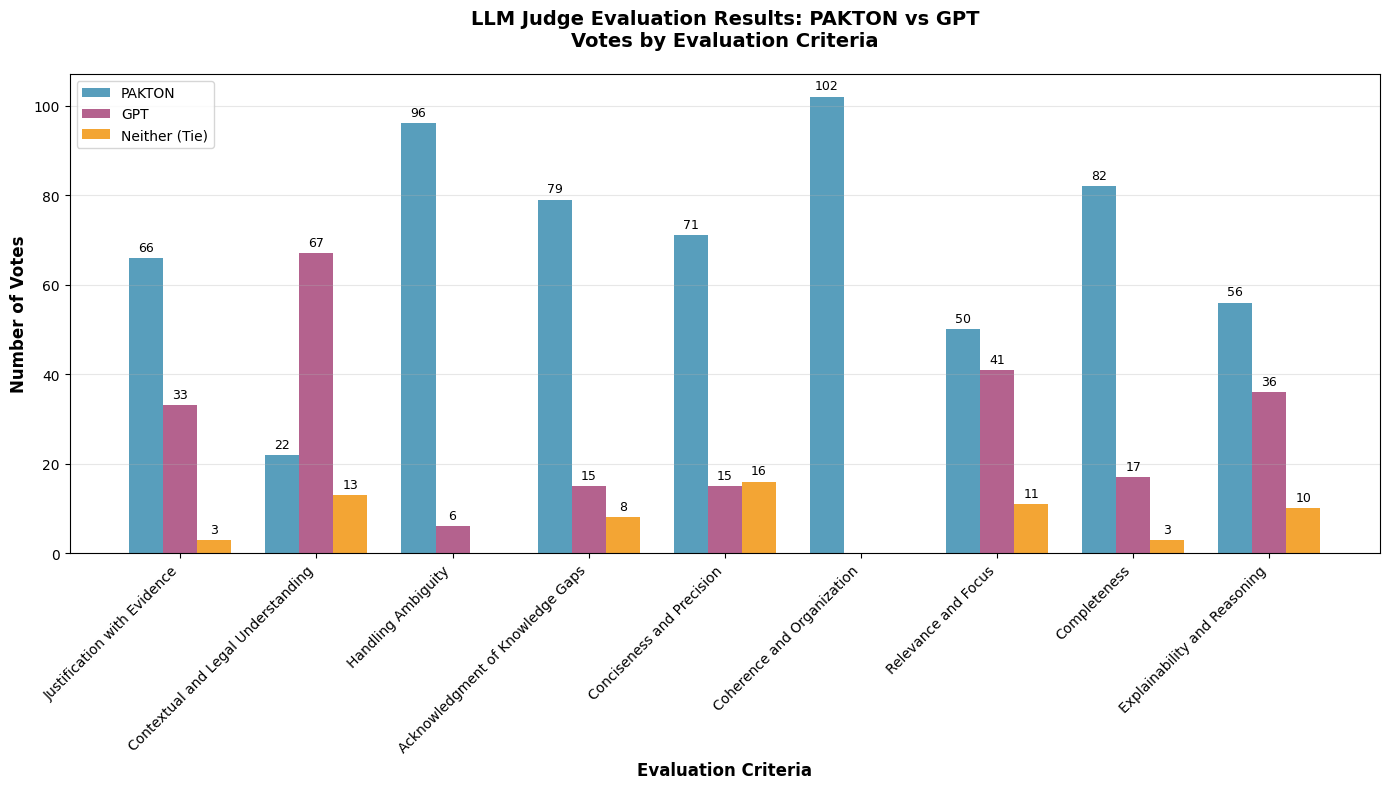

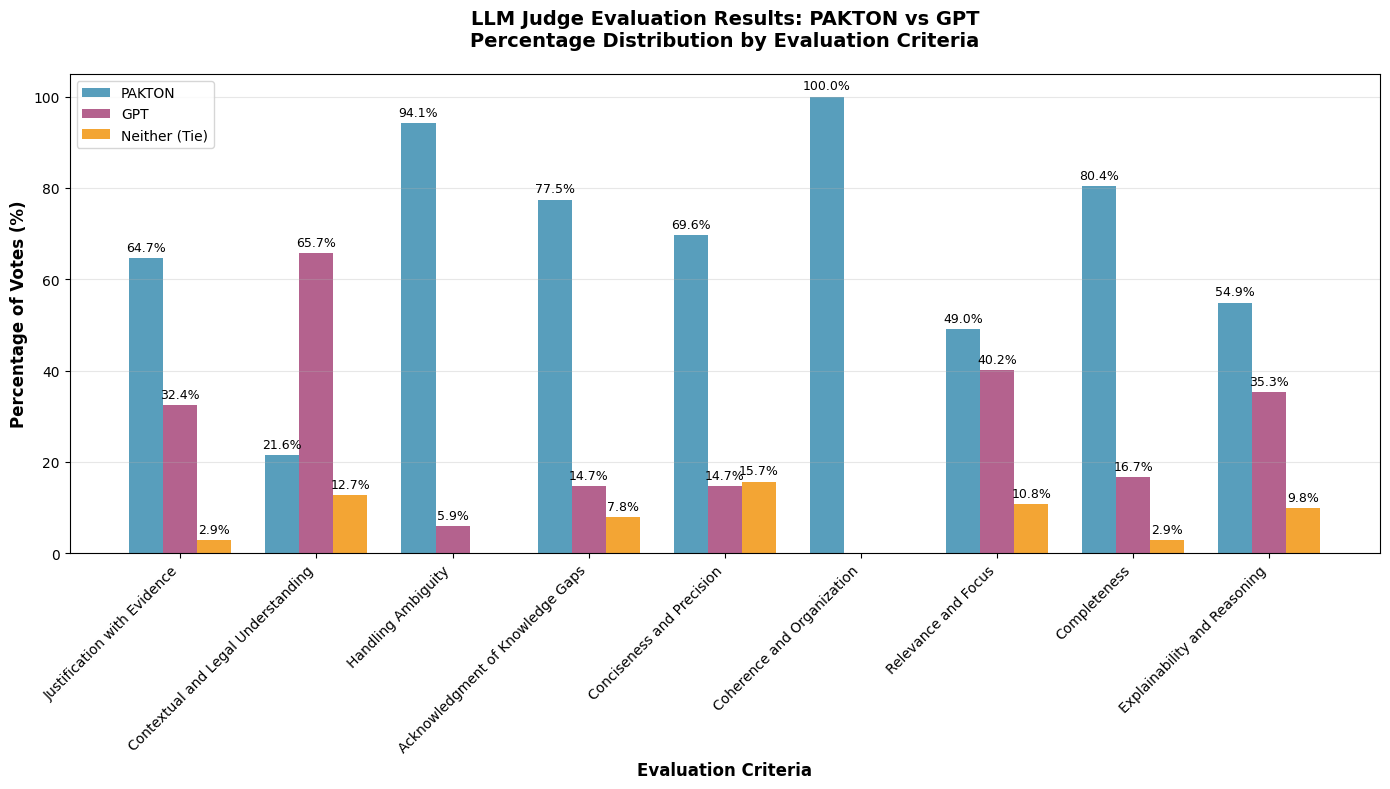

Charts displayed above show:
1. Absolute vote counts by criterion
2. Percentage distribution by criterion


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create a DataFrame from the results for easier plotting
plot_data = []
for criterion, votes in final_results.items():
    plot_data.append({
        'Criterion': criterion,
        'PAKTON': votes['PAKTON'],
        'GPT': votes['GPT'],
        'Neither': votes['Neither']
    })

df = pd.DataFrame(plot_data)

# Set up the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Define the positions and width of bars
x = np.arange(len(df))
width = 0.25

# Create bars
bars1 = ax.bar(x - width, df['PAKTON'], width, label='PAKTON', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x, df['GPT'], width, label='GPT', color='#A23B72', alpha=0.8)
bars3 = ax.bar(x + width, df['Neither'], width, label='Neither (Tie)', color='#F18F01', alpha=0.8)

# Customize the plot
ax.set_xlabel('Evaluation Criteria', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Votes', fontsize=12, fontweight='bold')
ax.set_title('LLM Judge Evaluation Results: PAKTON vs GPT\nVotes by Evaluation Criteria', 
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis labels with rotation for better readability
ax.set_xticks(x)
ax.set_xticklabels(df['Criterion'], rotation=45, ha='right')

# Add legend
ax.legend(loc='upper left', fontsize=10)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only show label if height > 0
            ax.annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

# Improve layout
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

# Show the plot
plt.show()

# Also create a percentage-based plot
fig2, ax2 = plt.subplots(figsize=(14, 8))

# Calculate percentages
df['Total'] = df['PAKTON'] + df['GPT'] + df['Neither']
df['PAKTON_pct'] = (df['PAKTON'] / df['Total']) * 100
df['GPT_pct'] = (df['GPT'] / df['Total']) * 100
df['Neither_pct'] = (df['Neither'] / df['Total']) * 100

# Create percentage bars
bars1_pct = ax2.bar(x - width, df['PAKTON_pct'], width, label='PAKTON', color='#2E86AB', alpha=0.8)
bars2_pct = ax2.bar(x, df['GPT_pct'], width, label='GPT', color='#A23B72', alpha=0.8)
bars3_pct = ax2.bar(x + width, df['Neither_pct'], width, label='Neither (Tie)', color='#F18F01', alpha=0.8)

# Customize the percentage plot
ax2.set_xlabel('Evaluation Criteria', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage of Votes (%)', fontsize=12, fontweight='bold')
ax2.set_title('LLM Judge Evaluation Results: PAKTON vs GPT\nPercentage Distribution by Evaluation Criteria', 
              fontsize=14, fontweight='bold', pad=20)

ax2.set_xticks(x)
ax2.set_xticklabels(df['Criterion'], rotation=45, ha='right')
ax2.legend(loc='upper left', fontsize=10)

# Add percentage labels on bars
def add_percentage_labels(bars, values):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if height > 0:  # Only show label if height > 0
            ax2.annotate(f'{value:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

add_percentage_labels(bars1_pct, df['PAKTON_pct'])
add_percentage_labels(bars2_pct, df['GPT_pct'])
add_percentage_labels(bars3_pct, df['Neither_pct'])

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Charts displayed above show:")
print("1. Absolute vote counts by criterion")
print("2. Percentage distribution by criterion")

Excluded 45 'I am not sure' votes from human data analysis
Human data now only includes: PAKTON, GPT, and Neither votes


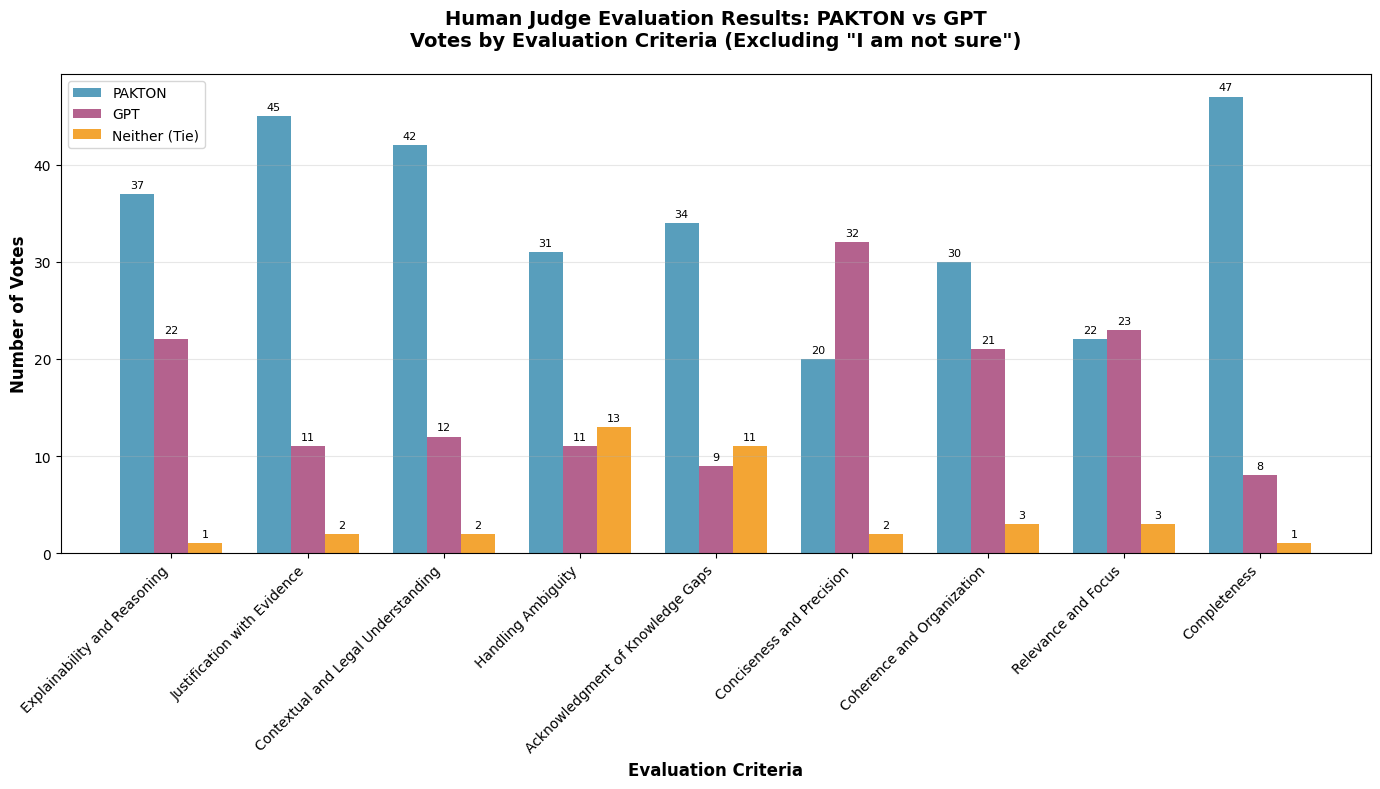

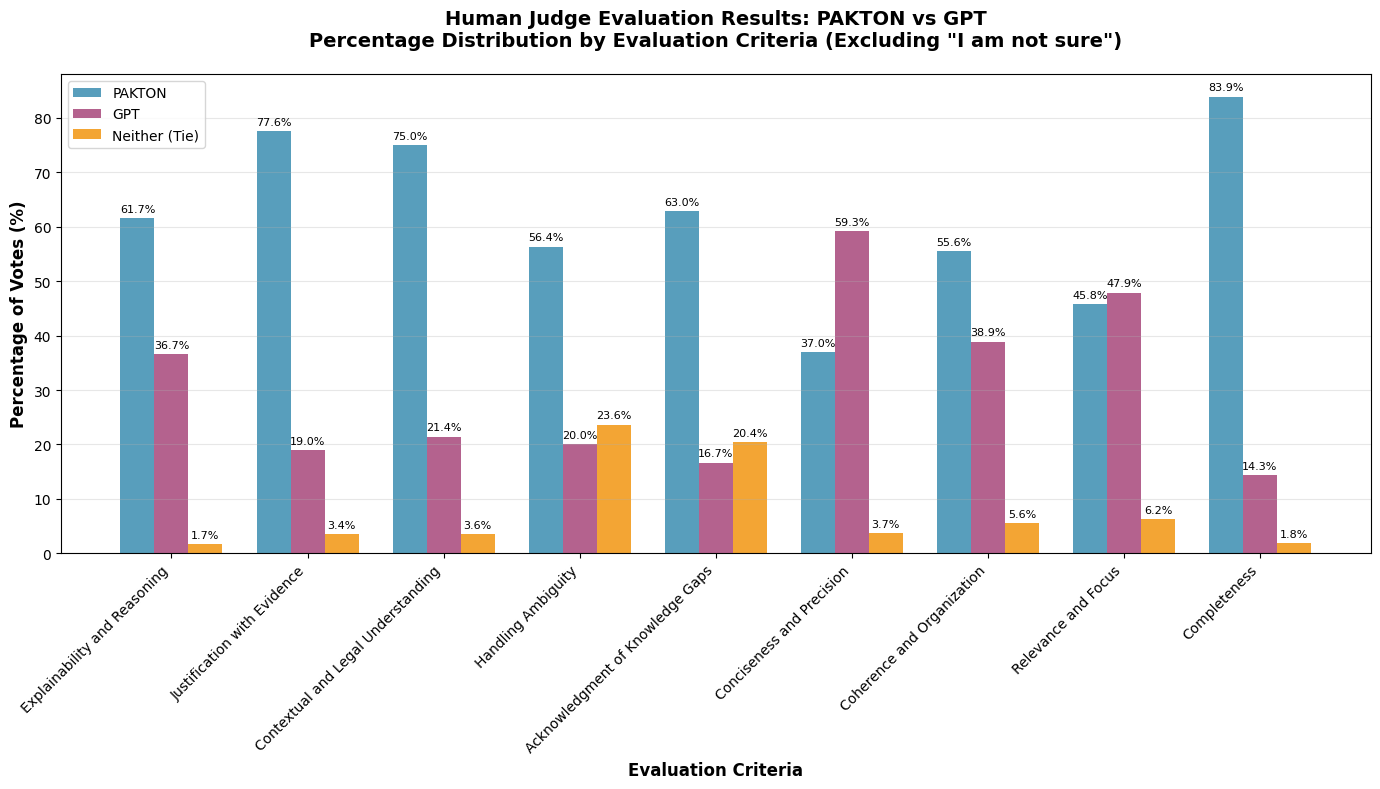

HUMAN JUDGE SUMMARY STATISTICS (EXCLUDING 'I am not sure' votes)
Total human evaluations (excluding 'I am not sure'): 495
Excluded 'I am not sure' votes: 45
PAKTON wins: 308 (62.2%)
GPT wins: 149 (30.1%)
Ties: 38 (7.7%)

Human vs LLM Judge Comparison (both excluding uncertain votes):
PAKTON win rate - Human: 62.2% vs LLM: 68.0%
GPT win rate - Human: 30.1% vs LLM: 25.1%


In [7]:
# Load and visualize human aggregated votes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

with open('human_aggregated_votes.json', 'r') as f:
    human_data_raw = json.load(f)

# Process human data by excluding 'I am not sure' votes
human_data = {}
total_human_unsure_excluded = 0

for criterion, votes in human_data_raw.items():
    # Exclude 'I am not sure' votes from the calculation
    human_data[criterion] = {
        'PAKTON': votes['PAKTON'],
        'GPT': votes['GPT'],
        'Neither': votes['Neither']
    }
    total_human_unsure_excluded += votes['I am not sure']

print(f"Excluded {total_human_unsure_excluded} 'I am not sure' votes from human data analysis")
print("Human data now only includes: PAKTON, GPT, and Neither votes")

# Create a DataFrame from the human results (without 'I am not sure')
human_plot_data = []
for criterion, votes in human_data.items():
    human_plot_data.append({
        'Criterion': criterion,
        'PAKTON': votes['PAKTON'],
        'GPT': votes['GPT'],
        'Neither': votes['Neither']
    })

human_df = pd.DataFrame(human_plot_data)

# Set up the plot for absolute counts (now with 3 categories instead of 4)
fig, ax = plt.subplots(figsize=(14, 8))

# Define the positions and width of bars
x = np.arange(len(human_df))
width = 0.25  # Increased width since we have one less category

# Create bars (removed 'I am not sure' category)
bars1 = ax.bar(x - width, human_df['PAKTON'], width, label='PAKTON', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x, human_df['GPT'], width, label='GPT', color='#A23B72', alpha=0.8)
bars3 = ax.bar(x + width, human_df['Neither'], width, label='Neither (Tie)', color='#F18F01', alpha=0.8)

# Customize the plot
ax.set_xlabel('Evaluation Criteria', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Votes', fontsize=12, fontweight='bold')
ax.set_title('Human Judge Evaluation Results: PAKTON vs GPT\nVotes by Evaluation Criteria (Excluding "I am not sure")', 
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis labels with rotation for better readability
ax.set_xticks(x)
ax.set_xticklabels(human_df['Criterion'], rotation=45, ha='right')

# Add legend
ax.legend(loc='upper left', fontsize=10)

# Add value labels on bars
def add_value_labels_human(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only show label if height > 0
            ax.annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=8)

add_value_labels_human(bars1)
add_value_labels_human(bars2)
add_value_labels_human(bars3)

# Improve layout
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

# Show the plot
plt.show()

# Create a percentage-based plot for human data (excluding 'I am not sure')
fig2, ax2 = plt.subplots(figsize=(14, 8))

# Calculate percentages (now based only on PAKTON, GPT, Neither)
human_df['Total'] = human_df['PAKTON'] + human_df['GPT'] + human_df['Neither']
human_df['PAKTON_pct'] = (human_df['PAKTON'] / human_df['Total']) * 100
human_df['GPT_pct'] = (human_df['GPT'] / human_df['Total']) * 100
human_df['Neither_pct'] = (human_df['Neither'] / human_df['Total']) * 100

# Create percentage bars (3 categories instead of 4)
bars1_pct = ax2.bar(x - width, human_df['PAKTON_pct'], width, label='PAKTON', color='#2E86AB', alpha=0.8)
bars2_pct = ax2.bar(x, human_df['GPT_pct'], width, label='GPT', color='#A23B72', alpha=0.8)
bars3_pct = ax2.bar(x + width, human_df['Neither_pct'], width, label='Neither (Tie)', color='#F18F01', alpha=0.8)

# Customize the percentage plot
ax2.set_xlabel('Evaluation Criteria', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage of Votes (%)', fontsize=12, fontweight='bold')
ax2.set_title('Human Judge Evaluation Results: PAKTON vs GPT\nPercentage Distribution by Evaluation Criteria (Excluding "I am not sure")', 
              fontsize=14, fontweight='bold', pad=20)

ax2.set_xticks(x)
ax2.set_xticklabels(human_df['Criterion'], rotation=45, ha='right')
ax2.legend(loc='upper left', fontsize=10)

# Add percentage labels on bars
def add_percentage_labels_human(bars, values):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if height > 0:  # Only show label if height > 0
            ax2.annotate(f'{value:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=8)

add_percentage_labels_human(bars1_pct, human_df['PAKTON_pct'])
add_percentage_labels_human(bars2_pct, human_df['GPT_pct'])
add_percentage_labels_human(bars3_pct, human_df['Neither_pct'])

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Display summary statistics for human data (excluding 'I am not sure')
print("=" * 80)
print("HUMAN JUDGE SUMMARY STATISTICS (EXCLUDING 'I am not sure' votes)")
print("=" * 80)
total_human_votes = sum(sum([votes['PAKTON'], votes['GPT'], votes['Neither']]) 
                       for votes in human_data.values())
total_human_pakton = sum(votes['PAKTON'] for votes in human_data.values())
total_human_gpt = sum(votes['GPT'] for votes in human_data.values())
total_human_ties = sum(votes['Neither'] for votes in human_data.values())

print(f"Total human evaluations (excluding 'I am not sure'): {total_human_votes}")
print(f"Excluded 'I am not sure' votes: {total_human_unsure_excluded}")
print(f"PAKTON wins: {total_human_pakton} ({total_human_pakton/total_human_votes*100:.1f}%)")
print(f"GPT wins: {total_human_gpt} ({total_human_gpt/total_human_votes*100:.1f}%)")
print(f"Ties: {total_human_ties} ({total_human_ties/total_human_votes*100:.1f}%)")

print("\nHuman vs LLM Judge Comparison (both excluding uncertain votes):")
print(f"PAKTON win rate - Human: {total_human_pakton/total_human_votes*100:.1f}% vs LLM: {total_pakton_wins/total_votes_all*100:.1f}%")
print(f"GPT win rate - Human: {total_human_gpt/total_human_votes*100:.1f}% vs LLM: {total_gpt_wins/total_votes_all*100:.1f}%")

In [8]:
# Demonstration: Impact of Excluding 'I am not sure' Votes
print("=" * 80)
print("IMPACT OF EXCLUDING 'I am not sure' VOTES FROM HUMAN DATA")
print("=" * 80)

# Load original data to show comparison
with open('human_aggregated_votes.json', 'r') as f:
    original_human_data = json.load(f)

# Show before and after for a few criteria
print("BEFORE vs AFTER PERCENTAGES (Sample Criteria):")
print("=" * 60)

sample_criteria = list(original_human_data.keys())[:3]  # Show first 3 criteria
for criterion in sample_criteria:
    # Original percentages (including 'I am not sure')
    orig_votes = original_human_data[criterion]
    orig_total = sum(orig_votes.values())
    orig_pak_pct = (orig_votes['PAKTON'] / orig_total) * 100
    orig_gpt_pct = (orig_votes['GPT'] / orig_total) * 100
    orig_neither_pct = (orig_votes['Neither'] / orig_total) * 100
    orig_unsure_pct = (orig_votes['I am not sure'] / orig_total) * 100
    
    # New percentages (excluding 'I am not sure')
    new_votes = human_data[criterion]
    new_total = sum(new_votes.values())
    new_pak_pct = (new_votes['PAKTON'] / new_total) * 100
    new_gpt_pct = (new_votes['GPT'] / new_total) * 100
    new_neither_pct = (new_votes['Neither'] / new_total) * 100
    
    print(f"\n{criterion}:")
    print(f"  ORIGINAL (with unsure): PAKTON={orig_pak_pct:.1f}%, GPT={orig_gpt_pct:.1f}%, Neither={orig_neither_pct:.1f}%, Unsure={orig_unsure_pct:.1f}%")
    print(f"  UPDATED (no unsure):    PAKTON={new_pak_pct:.1f}%, GPT={new_gpt_pct:.1f}%, Neither={new_neither_pct:.1f}%")
    print(f"  Change in PAKTON: {new_pak_pct - orig_pak_pct:+.1f} percentage points")
    print(f"  Change in GPT: {new_gpt_pct - orig_gpt_pct:+.1f} percentage points")

print(f"\n📊 SUMMARY:")
print(f"• Total 'I am not sure' votes excluded: {total_human_unsure_excluded}")
print(f"• This approach treats uncertain human judgments as non-votes")
print(f"• Percentages are now calculated only among definitive human choices")
print(f"• This makes human data more comparable to LLM Judge (which has no uncertainty)")

print(f"\n🎯 RATIONALE:")
print(f"• LLM Judge always makes a definitive choice (PAKTON, GPT, or Neither)")
print(f"• By excluding 'I am not sure' votes, we compare only confident human judgments")
print(f"• This may provide a fairer comparison of decision-making patterns")
print(f"• However, this also removes information about human uncertainty")

IMPACT OF EXCLUDING 'I am not sure' VOTES FROM HUMAN DATA
BEFORE vs AFTER PERCENTAGES (Sample Criteria):

Explainability and Reasoning:
  ORIGINAL (with unsure): PAKTON=61.7%, GPT=36.7%, Neither=1.7%, Unsure=0.0%
  UPDATED (no unsure):    PAKTON=61.7%, GPT=36.7%, Neither=1.7%
  Change in PAKTON: +0.0 percentage points
  Change in GPT: +0.0 percentage points

Justification with Evidence:
  ORIGINAL (with unsure): PAKTON=75.0%, GPT=18.3%, Neither=3.3%, Unsure=3.3%
  UPDATED (no unsure):    PAKTON=77.6%, GPT=19.0%, Neither=3.4%
  Change in PAKTON: +2.6 percentage points
  Change in GPT: +0.6 percentage points

Contextual and Legal Understanding:
  ORIGINAL (with unsure): PAKTON=70.0%, GPT=20.0%, Neither=3.3%, Unsure=6.7%
  UPDATED (no unsure):    PAKTON=75.0%, GPT=21.4%, Neither=3.6%
  Change in PAKTON: +5.0 percentage points
  Change in GPT: +1.4 percentage points

📊 SUMMARY:
• Total 'I am not sure' votes excluded: 45
• This approach treats uncertain human judgments as non-votes
• Percen

Run the following cell to have all criteria (including 'Contextual and Legal Understanding')

In [53]:
criteria = ['Justification with Evidence', 'Contextual and Legal Understanding', 'Handling Ambiguity', 'Acknowledgment of Knowledge Gaps', 'Conciseness and Precision', 'Coherence and Organization', 'Relevance and Focus', 'Completeness', 'Explainability and Reasoning']

Run the following cell to have all criteria except 'Contextual and Legal Understanding'

In [9]:
criteria = ['Justification with Evidence', 'Handling Ambiguity', 'Acknowledgment of Knowledge Gaps', 'Conciseness and Precision', 'Coherence and Organization', 'Relevance and Focus', 'Completeness', 'Explainability and Reasoning']

In [10]:
# Statistical Agreement Analysis for Percentage Distributions
import numpy as np
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("STATISTICAL AGREEMENT ANALYSIS FOR PERCENTAGE DISTRIBUTIONS")
print("=" * 80)

# Prepare aligned percentage data for each criterion
alignment_results = []

for criterion in criteria:
    if criterion in human_data:
        # LLM Judge percentages
        llm_votes = final_results[criterion]
        llm_total = sum(llm_votes.values())
        llm_pakton_pct = (llm_votes['PAKTON'] / llm_total) * 100
        llm_gpt_pct = (llm_votes['GPT'] / llm_total) * 100
        llm_neither_pct = (llm_votes['Neither'] / llm_total) * 100
        llm_unsure_pct = 0  # LLM has no "unsure" category
        
        # Human percentages (excluding 'I am not sure' votes)
        human_votes = human_data[criterion]
        human_total = sum(human_votes.values())  # Now only PAKTON, GPT, Neither
        human_pakton_pct = (human_votes['PAKTON'] / human_total) * 100
        human_gpt_pct = (human_votes['GPT'] / human_total) * 100
        human_neither_pct = (human_votes['Neither'] / human_total) * 100
        human_unsure_pct = 0  # Set to 0 since we're excluding these votes
        
        alignment_results.append({
            'criterion': criterion,
            'llm_pakton_pct': llm_pakton_pct,
            'llm_gpt_pct': llm_gpt_pct,
            'llm_neither_pct': llm_neither_pct,
            'llm_unsure_pct': llm_unsure_pct,
            'human_pakton_pct': human_pakton_pct,
            'human_gpt_pct': human_gpt_pct,
            'human_neither_pct': human_neither_pct,
            'human_unsure_pct': human_unsure_pct
        })

alignment_df = pd.DataFrame(alignment_results)
print(f"Analyzing percentage alignment across {len(alignment_df)} criteria\n")

# Display the percentage comparison table
print("PERCENTAGE COMPARISON BY CRITERION:")
print("=" * 100)
print(f"{'Criterion':<20} {'LLM PAKTON':<12} {'Human PAKTON':<14} {'LLM GPT':<10} {'Human GPT':<12} {'LLM Neither':<13} {'Human Neither':<15} {'Human Unsure':<13}")
print("-" * 100)
for _, row in alignment_df.iterrows():
    print(f"{row['criterion']:<20} {row['llm_pakton_pct']:<12.1f} {row['human_pakton_pct']:<14.1f} "
          f"{row['llm_gpt_pct']:<10.1f} {row['human_gpt_pct']:<12.1f} {row['llm_neither_pct']:<13.1f} "
          f"{row['human_neither_pct']:<15.1f} {row['human_unsure_pct']:<13.1f}")

STATISTICAL AGREEMENT ANALYSIS FOR PERCENTAGE DISTRIBUTIONS
Analyzing percentage alignment across 8 criteria

PERCENTAGE COMPARISON BY CRITERION:
Criterion            LLM PAKTON   Human PAKTON   LLM GPT    Human GPT    LLM Neither   Human Neither   Human Unsure 
----------------------------------------------------------------------------------------------------
Justification with Evidence 64.7         77.6           32.4       19.0         2.9           3.4             0.0          
Handling Ambiguity   94.1         56.4           5.9        20.0         0.0           23.6            0.0          
Acknowledgment of Knowledge Gaps 77.5         63.0           14.7       16.7         7.8           20.4            0.0          
Conciseness and Precision 69.6         37.0           14.7       59.3         15.7          3.7             0.0          
Coherence and Organization 100.0        55.6           0.0        38.9         0.0           5.6             0.0          
Relevance and Focus  

In [11]:
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# 1. Pearson Correlation for each category
categories = ['PAKTON', 'GPT', 'Neither']
correlation_results = {}

for category in categories:
    llm_values = alignment_df[f'llm_{category.lower()}_pct'].values
    human_values = alignment_df[f'human_{category.lower()}_pct'].values
    
    pearson_corr, pearson_p = pearsonr(llm_values, human_values)
    spearman_corr, spearman_p = spearmanr(llm_values, human_values)
    
    correlation_results[category] = {
        'pearson_r': pearson_corr,
        'pearson_p': pearson_p,
        'spearman_r': spearman_corr,
        'spearman_p': spearman_p
    }
    
    print(f"\n{category} Category:")
    print(f"  Pearson correlation: r = {pearson_corr:.4f}, p = {pearson_p:.4f}")
    print(f"  Spearman correlation: ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")
    print(f"  Interpretation: {'Strong' if abs(pearson_corr) > 0.7 else 'Moderate' if abs(pearson_corr) > 0.4 else 'Weak'} linear relationship")

# 2. Overall distribution similarity metrics
print("\n" + "=" * 80)
print("DISTRIBUTION SIMILARITY METRICS")
print("=" * 80)

# Calculate metrics for each criterion
similarity_metrics = []

for _, row in alignment_df.iterrows():
    llm_dist = [row['llm_pakton_pct'], row['llm_gpt_pct'], row['llm_neither_pct'], row['llm_unsure_pct']]
    human_dist = [row['human_pakton_pct'], row['human_gpt_pct'], row['human_neither_pct'], row['human_unsure_pct']]
    
    # Mean Absolute Error (MAE)
    mae = mean_absolute_error([llm_dist], [human_dist])
    
    # Root Mean Square Error (RMSE)
    rmse = np.sqrt(mean_squared_error([llm_dist], [human_dist]))
    
    # Cosine Similarity (1 - cosine distance)
    cosine_sim = 1 - cosine(llm_dist, human_dist)
    
    # Manhattan Distance
    manhattan_dist = sum(abs(l - h) for l, h in zip(llm_dist, human_dist))
    
    # Euclidean Distance
    euclidean_dist = np.sqrt(sum((l - h)**2 for l, h in zip(llm_dist, human_dist)))
    
    similarity_metrics.append({
        'criterion': row['criterion'],
        'mae': mae,
        'rmse': rmse,
        'cosine_similarity': cosine_sim,
        'manhattan_distance': manhattan_dist,
        'euclidean_distance': euclidean_dist
    })

similarity_df = pd.DataFrame(similarity_metrics)

# Display summary statistics
print(f"Average Mean Absolute Error (MAE): {similarity_df['mae'].mean():.2f}%")
print(f"Average Root Mean Square Error (RMSE): {similarity_df['rmse'].mean():.2f}%")
print(f"Average Cosine Similarity: {similarity_df['cosine_similarity'].mean():.4f}")
print(f"Average Manhattan Distance: {similarity_df['manhattan_distance'].mean():.2f}%")
print(f"Average Euclidean Distance: {similarity_df['euclidean_distance'].mean():.2f}%")

print(f"\nBest Agreement (lowest MAE): {similarity_df.loc[similarity_df['mae'].idxmin(), 'criterion']} (MAE: {similarity_df['mae'].min():.2f}%)")
print(f"Worst Agreement (highest MAE): {similarity_df.loc[similarity_df['mae'].idxmax(), 'criterion']} (MAE: {similarity_df['mae'].max():.2f}%)")

print(f"\nHighest Cosine Similarity: {similarity_df.loc[similarity_df['cosine_similarity'].idxmax(), 'criterion']} ({similarity_df['cosine_similarity'].max():.4f})")
print(f"Lowest Cosine Similarity: {similarity_df.loc[similarity_df['cosine_similarity'].idxmin(), 'criterion']} ({similarity_df['cosine_similarity'].min():.4f})")

# Display detailed metrics table
print("\n" + "=" * 120)
print("DETAILED SIMILARITY METRICS BY CRITERION:")
print("=" * 120)
print(f"{'Criterion':<20} {'MAE':<8} {'RMSE':<8} {'Cosine Sim':<12} {'Manhattan':<12} {'Euclidean':<12}")
print("-" * 120)
for _, row in similarity_df.iterrows():
    print(f"{row['criterion']:<20} {row['mae']:<8.2f} {row['rmse']:<8.2f} {row['cosine_similarity']:<12.4f} "
          f"{row['manhattan_distance']:<12.2f} {row['euclidean_distance']:<12.2f}")


CORRELATION ANALYSIS

PAKTON Category:
  Pearson correlation: r = 0.1220, p = 0.7736
  Spearman correlation: ρ = 0.1190, p = 0.7789
  Interpretation: Weak linear relationship

GPT Category:
  Pearson correlation: r = 0.1545, p = 0.7148
  Spearman correlation: ρ = 0.0240, p = 0.9551
  Interpretation: Weak linear relationship

Neither Category:
  Pearson correlation: r = -0.2859, p = 0.4924
  Spearman correlation: ρ = -0.2410, p = 0.5653
  Interpretation: Weak linear relationship

DISTRIBUTION SIMILARITY METRICS
Average Mean Absolute Error (MAE): 10.88%
Average Root Mean Square Error (RMSE): 14.06%
Average Cosine Similarity: 0.9164
Average Manhattan Distance: 43.51%
Average Euclidean Distance: 28.12%

Best Agreement (lowest MAE): Completeness (MAE: 1.77%)
Worst Agreement (highest MAE): Conciseness and Precision (MAE: 22.28%)

Highest Cosine Similarity: Completeness (0.9992)
Lowest Cosine Similarity: Conciseness and Precision (0.6880)

DETAILED SIMILARITY METRICS BY CRITERION:
Criterion 

In [12]:
# Additional Statistical Analysis: Variance, Standard Deviation, and More
from scipy import stats
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 80)
print("COMPREHENSIVE STATISTICAL ANALYSIS")
print("=" * 80)

# 1. Variance and Standard Deviation Analysis
print("\nVARIANCE AND STANDARD DEVIATION ANALYSIS:")
print("=" * 60)

variance_results = {}
for category in categories:
    llm_values = alignment_df[f'llm_{category.lower()}_pct'].values
    human_values = alignment_df[f'human_{category.lower()}_pct'].values
    
    # Calculate variance and standard deviation
    llm_var = np.var(llm_values, ddof=1)  # Sample variance
    human_var = np.var(human_values, ddof=1)
    llm_std = np.std(llm_values, ddof=1)  # Sample standard deviation
    human_std = np.std(human_values, ddof=1)
    
    # Calculate coefficient of variation (CV = std/mean)
    llm_cv = llm_std / np.mean(llm_values) * 100 if np.mean(llm_values) != 0 else 0
    human_cv = human_std / np.mean(human_values) * 100 if np.mean(human_values) != 0 else 0
    
    # F-test for equality of variances
    f_statistic = llm_var / human_var if human_var != 0 else np.inf
    f_p_value = 2 * min(stats.f.cdf(f_statistic, len(llm_values)-1, len(human_values)-1),
                       1 - stats.f.cdf(f_statistic, len(llm_values)-1, len(human_values)-1))
    
    variance_results[category] = {
        'llm_var': llm_var,
        'human_var': human_var,
        'llm_std': llm_std,
        'human_std': human_std,
        'llm_cv': llm_cv,
        'human_cv': human_cv,
        'f_statistic': f_statistic,
        'f_p_value': f_p_value,
        'var_ratio': llm_var / human_var if human_var != 0 else np.inf
    }
    
    print(f"\n{category} Category:")
    print(f"  LLM Variance: {llm_var:.3f}, Human Variance: {human_var:.3f}")
    print(f"  LLM Std Dev: {llm_std:.3f}, Human Std Dev: {human_std:.3f}")
    print(f"  LLM CV: {llm_cv:.1f}%, Human CV: {human_cv:.1f}%")
    print(f"  Variance Ratio (LLM/Human): {llm_var/human_var:.3f}" if human_var != 0 else "  Variance Ratio: undefined")
    print(f"  F-test for equal variances: F={f_statistic:.3f}, p={f_p_value:.4f}")
    
    if f_p_value < 0.05:
        print(f"  → Variances are significantly different (p < 0.05)")
    else:
        print(f"  → Variances are not significantly different (p ≥ 0.05)")

# 2. Additional Correlation and Regression Metrics
print(f"\n" + "=" * 60)
print("EXTENDED CORRELATION AND REGRESSION ANALYSIS:")
print("=" * 60)

extended_results = {}
for category in categories:
    llm_values = alignment_df[f'llm_{category.lower()}_pct'].values
    human_values = alignment_df[f'human_{category.lower()}_pct'].values
    
    # R-squared (coefficient of determination)
    try:
        r2 = r2_score(human_values, llm_values)
    except:
        r2 = np.nan
    
    # Kendall's tau correlation
    kendall_tau, kendall_p = stats.kendalltau(llm_values, human_values)
    
    # Lin's Concordance Correlation Coefficient (CCC)
    def concordance_correlation_coefficient(x, y):
        """Calculate Lin's concordance correlation coefficient"""
        mean_x, mean_y = np.mean(x), np.mean(y)
        var_x, var_y = np.var(x, ddof=1), np.var(y, ddof=1)
        covariance = np.cov(x, y, ddof=1)[0, 1]
        
        numerator = 2 * covariance
        denominator = var_x + var_y + (mean_x - mean_y)**2
        
        return numerator / denominator if denominator != 0 else 0
    
    ccc = concordance_correlation_coefficient(llm_values, human_values)
    
    # Intraclass Correlation Coefficient (ICC) approximation
    # Using two-way random effects model
    def calculate_icc(x, y):
        """Calculate ICC(2,1) - two-way random effects, single measurement"""
        data = np.column_stack([x, y])
        n_subjects, n_raters = data.shape
        
        # Calculate means
        grand_mean = np.mean(data)
        subject_means = np.mean(data, axis=1)
        rater_means = np.mean(data, axis=0)
        
        # Calculate sums of squares
        ss_total = np.sum((data - grand_mean)**2)
        ss_subjects = n_raters * np.sum((subject_means - grand_mean)**2)
        ss_raters = n_subjects * np.sum((rater_means - grand_mean)**2)
        ss_error = ss_total - ss_subjects - ss_raters
        
        # Calculate mean squares
        ms_subjects = ss_subjects / (n_subjects - 1)
        ms_raters = ss_raters / (n_raters - 1)
        ms_error = ss_error / ((n_subjects - 1) * (n_raters - 1))
        
        # Calculate ICC(2,1)
        icc = (ms_subjects - ms_error) / (ms_subjects + (n_raters - 1) * ms_error + n_raters * (ms_raters - ms_error) / n_subjects)
        
        return max(0, min(1, icc))  # Bound between 0 and 1
    
    icc = calculate_icc(llm_values, human_values)
    
    # Mean and standard error of differences (Bland-Altman style)
    differences = llm_values - human_values
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)
    se_diff = std_diff / np.sqrt(len(differences))
    
    # 95% confidence interval for mean difference
    ci_lower = mean_diff - 1.96 * se_diff
    ci_upper = mean_diff + 1.96 * se_diff
    
    # Limits of agreement (mean ± 1.96*SD)
    loa_lower = mean_diff - 1.96 * std_diff
    loa_upper = mean_diff + 1.96 * std_diff
    
    extended_results[category] = {
        'r2': r2,
        'kendall_tau': kendall_tau,
        'kendall_p': kendall_p,
        'ccc': ccc,
        'icc': icc,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'se_diff': se_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'loa_lower': loa_lower,
        'loa_upper': loa_upper
    }
    
    print(f"\n{category} Category:")
    print(f"  R² (Coefficient of Determination): {r2:.4f}")
    print(f"  Kendall's τ: {kendall_tau:.4f} (p = {kendall_p:.4f})")
    print(f"  Lin's Concordance Correlation: {ccc:.4f}")
    print(f"  Intraclass Correlation (ICC): {icc:.4f}")
    print(f"  Mean Difference (LLM - Human): {mean_diff:.2f}% [95% CI: {ci_lower:.2f}, {ci_upper:.2f}]")
    print(f"  Limits of Agreement: [{loa_lower:.2f}, {loa_upper:.2f}]%")

# 3. Distribution Shape Analysis
print(f"\n" + "=" * 60)
print("DISTRIBUTION SHAPE ANALYSIS:")
print("=" * 60)

shape_results = {}
for category in categories:
    llm_values = alignment_df[f'llm_{category.lower()}_pct'].values
    human_values = alignment_df[f'human_{category.lower()}_pct'].values
    
    # Skewness and Kurtosis
    llm_skewness = stats.skew(llm_values)
    human_skewness = stats.skew(human_values)
    llm_kurtosis = stats.kurtosis(llm_values)
    human_kurtosis = stats.kurtosis(human_values)
    
    # Shapiro-Wilk test for normality
    llm_shapiro_stat, llm_shapiro_p = stats.shapiro(llm_values)
    human_shapiro_stat, human_shapiro_p = stats.shapiro(human_values)
    
    # Kolmogorov-Smirnov test comparing the two distributions
    ks_statistic, ks_p_value = stats.ks_2samp(llm_values, human_values)
    
    # Mann-Whitney U test (non-parametric alternative to t-test)
    mannwhitney_stat, mannwhitney_p = stats.mannwhitneyu(llm_values, human_values, alternative='two-sided')
    
    shape_results[category] = {
        'llm_skewness': llm_skewness,
        'human_skewness': human_skewness,
        'llm_kurtosis': llm_kurtosis,
        'human_kurtosis': human_kurtosis,
        'llm_shapiro_stat': llm_shapiro_stat,
        'llm_shapiro_p': llm_shapiro_p,
        'human_shapiro_stat': human_shapiro_stat,
        'human_shapiro_p': human_shapiro_p,
        'ks_statistic': ks_statistic,
        'ks_p_value': ks_p_value,
        'mannwhitney_stat': mannwhitney_stat,
        'mannwhitney_p': mannwhitney_p
    }
    
    print(f"\n{category} Category:")
    print(f"  Skewness - LLM: {llm_skewness:.3f}, Human: {human_skewness:.3f}")
    print(f"  Kurtosis - LLM: {llm_kurtosis:.3f}, Human: {human_kurtosis:.3f}")
    print(f"  Shapiro-Wilk (normality) - LLM: W={llm_shapiro_stat:.3f}, p={llm_shapiro_p:.4f}")
    print(f"  Shapiro-Wilk (normality) - Human: W={human_shapiro_stat:.3f}, p={human_shapiro_p:.4f}")
    print(f"  Kolmogorov-Smirnov (distribution equality): D={ks_statistic:.3f}, p={ks_p_value:.4f}")
    print(f"  Mann-Whitney U (median equality): U={mannwhitney_stat:.1f}, p={mannwhitney_p:.4f}")
    
    # Interpretation
    if ks_p_value < 0.05:
        print(f"  → Distributions are significantly different (K-S p < 0.05)")
    else:
        print(f"  → Distributions are not significantly different (K-S p ≥ 0.05)")

# 4. Summary Table of All Statistics
print(f"\n" + "=" * 80)
print("COMPREHENSIVE STATISTICS SUMMARY TABLE:")
print("=" * 80)

# Create a comprehensive summary
summary_stats = []
for category in categories:
    corr = correlation_results[category]
    var = variance_results[category]
    ext = extended_results[category]
    shape = shape_results[category]
    
    summary_stats.append({
        'Category': category,
        'Pearson r': f"{corr['pearson_r']:.3f}",
        'Spearman ρ': f"{corr['spearman_r']:.3f}",
        'Kendall τ': f"{ext['kendall_tau']:.3f}",
        'R²': f"{ext['r2']:.3f}",
        'CCC': f"{ext['ccc']:.3f}",
        'ICC': f"{ext['icc']:.3f}",
        'LLM Var': f"{var['llm_var']:.2f}",
        'Human Var': f"{var['human_var']:.2f}",
        'Var Ratio': f"{var['var_ratio']:.2f}",
        'Mean Diff': f"{ext['mean_diff']:.1f}%",
        'K-S p-val': f"{shape['ks_p_value']:.3f}"
    })

summary_df_stats = pd.DataFrame(summary_stats)
print(summary_df_stats.to_string(index=False, max_colwidth=15))

print(f"\n" + "=" * 60)
print("INTERPRETATION GUIDE:")
print("=" * 60)
print("• Pearson r: Linear correlation (-1 to 1, closer to ±1 = stronger linear relationship)")
print("• Spearman ρ: Rank correlation (robust to outliers)")
print("• Kendall τ: Alternative rank correlation (more robust, different calculation)")
print("• R²: Proportion of variance explained (0 to 1, higher = better fit)")
print("• CCC: Concordance correlation (agreement, 0 to 1, higher = better agreement)")
print("• ICC: Intraclass correlation (reliability, 0 to 1, higher = more reliable)")
print("• Var Ratio: LLM variance / Human variance (>1 = LLM more variable)")
print("• Mean Diff: Average difference LLM - Human (positive = LLM higher on average)")
print("• K-S p-val: Kolmogorov-Smirnov test (p < 0.05 = distributions significantly different)")

print(f"\n🔍 KEY INSIGHTS:")
for category in categories:
    var_ratio = variance_results[category]['var_ratio']
    mean_diff = extended_results[category]['mean_diff']
    ccc = extended_results[category]['ccc']
    
    print(f"\n{category}:")
    if var_ratio > 1.5:
        print(f"  • LLM shows much higher variability ({var_ratio:.2f}x more variable)")
    elif var_ratio < 0.67:
        print(f"  • Human shows much higher variability ({1/var_ratio:.2f}x more variable)")
    else:
        print(f"  • Similar variability between methods")
    
    if abs(mean_diff) > 10:
        direction = "higher" if mean_diff > 0 else "lower"
        print(f"  • LLM systematically {direction} than humans (avg diff: {mean_diff:.1f}%)")
    
    if ccc > 0.8:
        print(f"  • Excellent concordance (CCC = {ccc:.3f})")
    elif ccc > 0.6:
        print(f"  • Good concordance (CCC = {ccc:.3f})")
    else:
        print(f"  • Poor concordance (CCC = {ccc:.3f})")


COMPREHENSIVE STATISTICAL ANALYSIS

VARIANCE AND STANDARD DEVIATION ANALYSIS:

PAKTON Category:
  LLM Variance: 318.216, Human Variance: 236.324
  LLM Std Dev: 17.839, Human Std Dev: 15.373
  LLM CV: 24.2%, Human CV: 25.6%
  Variance Ratio (LLM/Human): 1.347
  F-test for equal variances: F=1.347, p=0.7046
  → Variances are not significantly different (p ≥ 0.05)

GPT Category:
  LLM Variance: 208.694, Human Variance: 275.292
  LLM Std Dev: 14.446, Human Std Dev: 16.592
  LLM CV: 72.3%, Human CV: 52.5%
  Variance Ratio (LLM/Human): 0.758
  F-test for equal variances: F=0.758, p=0.7241
  → Variances are not significantly different (p ≥ 0.05)

Neither Category:
  LLM Variance: 32.113, Human Variance: 74.819
  LLM Std Dev: 5.667, Human Std Dev: 8.650
  LLM CV: 90.7%, Human CV: 104.2%
  Variance Ratio (LLM/Human): 0.429
  F-test for equal variances: F=0.429, p=0.2869
  → Variances are not significantly different (p ≥ 0.05)

EXTENDED CORRELATION AND REGRESSION ANALYSIS:

PAKTON Category:
  R


VARIANCE AND STATISTICAL ANALYSIS VISUALIZATIONS


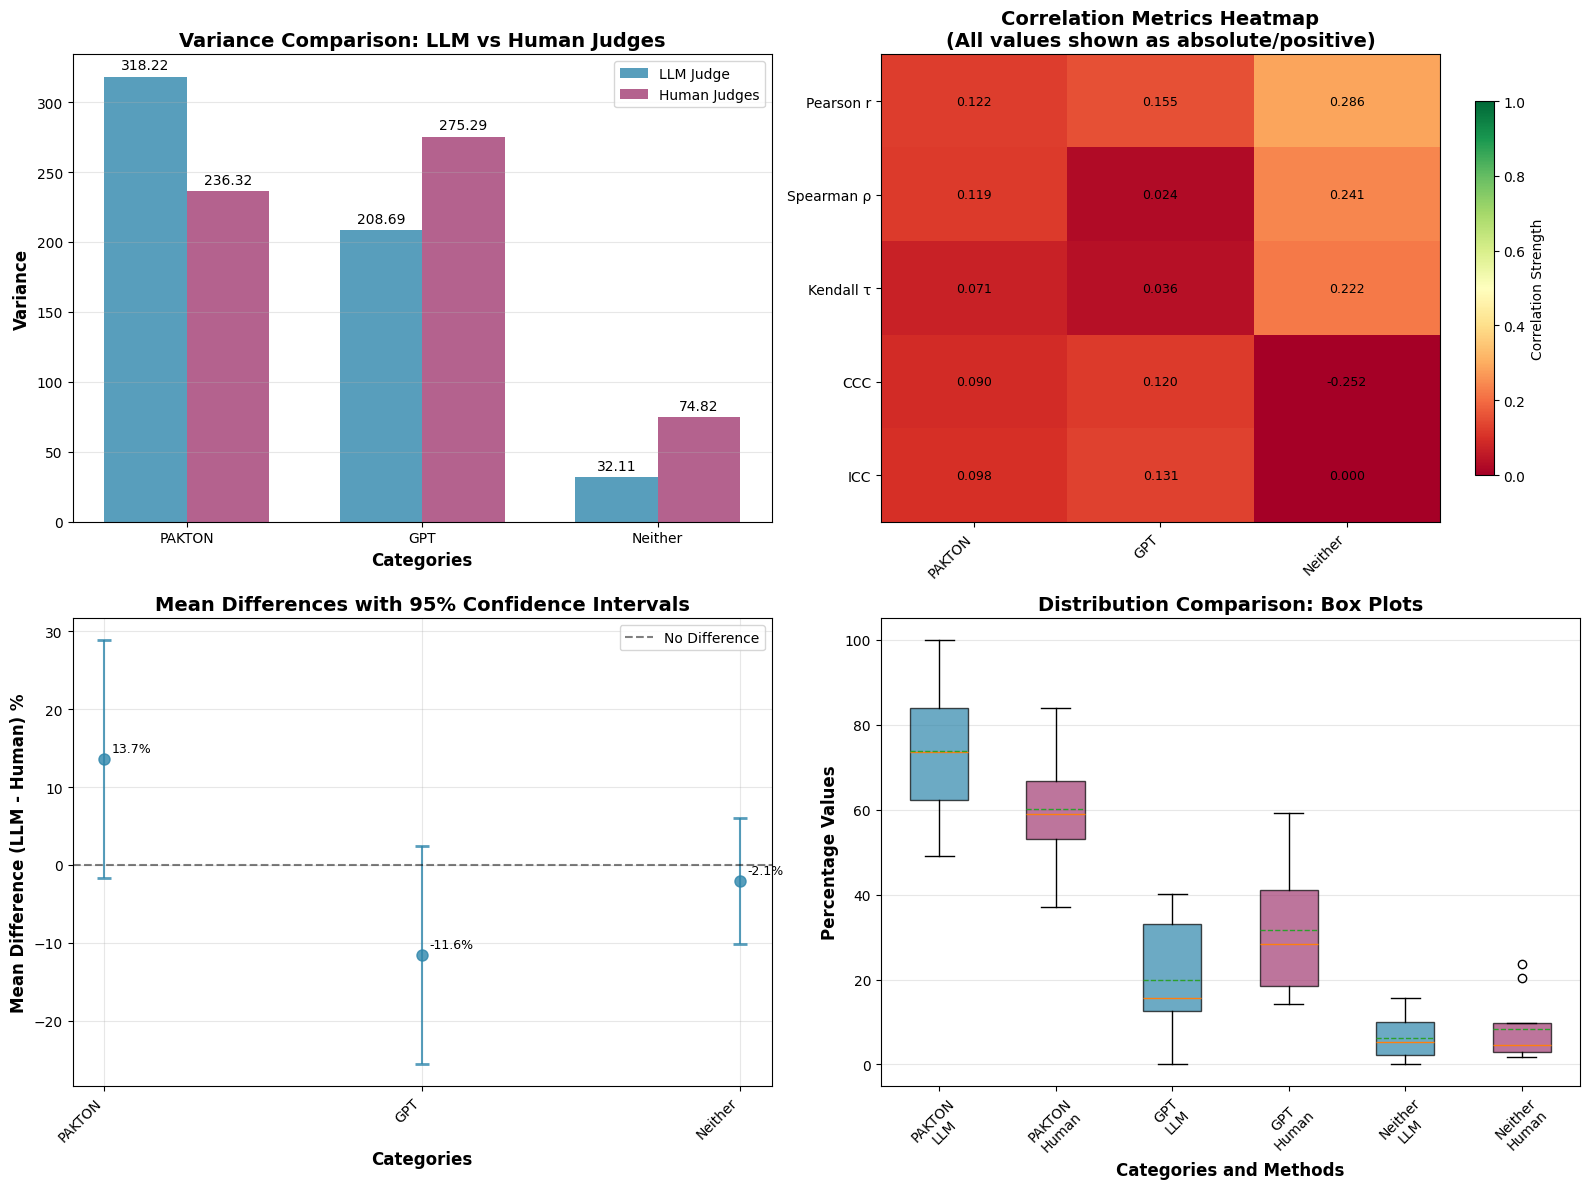

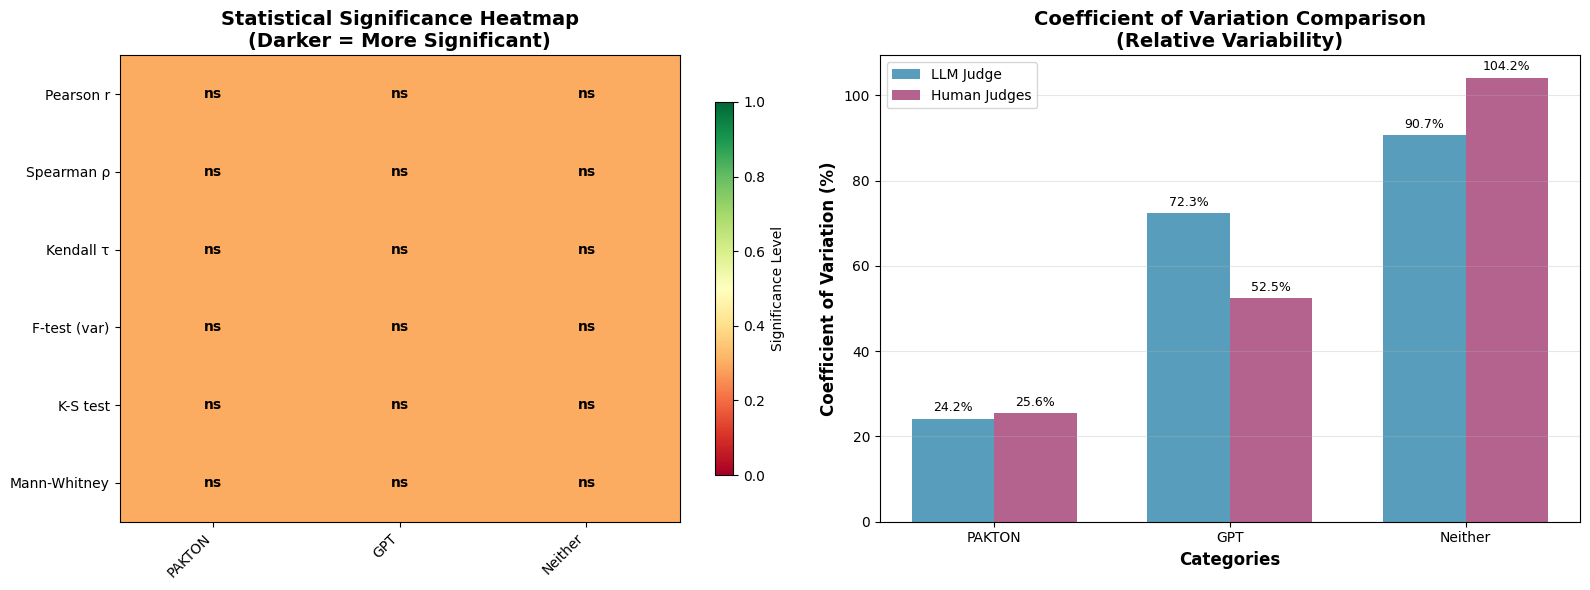


📊 VISUALIZATION GUIDE:
• Top Left: Variance comparison shows which method has more variability
• Top Right: Correlation metrics heatmap shows strength of relationships
• Bottom Left: Mean differences with confidence intervals show systematic bias
• Bottom Right: Box plots show distribution shapes and outliers
• Bottom panels: Significance heatmap (* p<0.05, ** p<0.01, *** p<0.001, ns = not significant)
• Coefficient of Variation: Higher values = more relative variability

🎯 QUICK INSIGHTS:
• Compare variance bars to see which method is more consistent
• Green areas in heatmaps indicate stronger relationships/significance
• Error bars crossing zero suggest no systematic difference
• Box plot spreads show distribution variability


In [52]:
# Visualizations for Variance and Statistical Analysis
print("\n" + "=" * 80)
print("VARIANCE AND STATISTICAL ANALYSIS VISUALIZATIONS")
print("=" * 80)

# Create a comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Variance Comparison
categories_list = list(categories)
llm_variances = [variance_results[cat]['llm_var'] for cat in categories_list]
human_variances = [variance_results[cat]['human_var'] for cat in categories_list]

x = np.arange(len(categories_list))
width = 0.35

bars1 = ax1.bar(x - width/2, llm_variances, width, label='LLM Judge', alpha=0.8, color='#2E86AB')
bars2 = ax1.bar(x + width/2, human_variances, width, label='Human Judges', alpha=0.8, color='#A23B72')

ax1.set_xlabel('Categories', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variance', fontsize=12, fontweight='bold')
ax1.set_title('Variance Comparison: LLM vs Human Judges', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories_list)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

# 2. Correlation Metrics Comparison
correlation_metrics = ['Pearson r', 'Spearman ρ', 'Kendall τ', 'CCC', 'ICC']
pearson_vals = [abs(correlation_results[cat]['pearson_r']) for cat in categories_list]
spearman_vals = [abs(correlation_results[cat]['spearman_r']) for cat in categories_list]
kendall_vals = [abs(extended_results[cat]['kendall_tau']) for cat in categories_list]
ccc_vals = [extended_results[cat]['ccc'] for cat in categories_list]
icc_vals = [extended_results[cat]['icc'] for cat in categories_list]

# Create a heatmap of correlation metrics
correlation_matrix = np.array([pearson_vals, spearman_vals, kendall_vals, ccc_vals, icc_vals])

im = ax2.imshow(correlation_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(categories_list)))
ax2.set_xticklabels(categories_list, rotation=45, ha='right')
ax2.set_yticks(range(len(correlation_metrics)))
ax2.set_yticklabels(correlation_metrics)
ax2.set_title('Correlation Metrics Heatmap\n(All values shown as absolute/positive)', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(correlation_metrics)):
    for j in range(len(categories_list)):
        text = ax2.text(j, i, f'{correlation_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Correlation Strength', fontsize=10)

# 3. Mean Differences with Error Bars (Bland-Altman style)
mean_diffs = [extended_results[cat]['mean_diff'] for cat in categories_list]
std_diffs = [extended_results[cat]['std_diff'] for cat in categories_list]
ci_lowers = [extended_results[cat]['ci_lower'] for cat in categories_list]
ci_uppers = [extended_results[cat]['ci_upper'] for cat in categories_list]

# Calculate error bar lengths
error_lower = [mean_diffs[i] - ci_lowers[i] for i in range(len(mean_diffs))]
error_upper = [ci_uppers[i] - mean_diffs[i] for i in range(len(mean_diffs))]

ax3.errorbar(range(len(categories_list)), mean_diffs, 
             yerr=[error_lower, error_upper], 
             fmt='o', capsize=5, capthick=2, markersize=8, 
             color='#2E86AB', ecolor='#2E86AB', alpha=0.8)

ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='No Difference')
ax3.set_xlabel('Categories', fontsize=12, fontweight='bold')
ax3.set_ylabel('Mean Difference (LLM - Human) %', fontsize=12, fontweight='bold')
ax3.set_title('Mean Differences with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax3.set_xticks(range(len(categories_list)))
ax3.set_xticklabels(categories_list, rotation=45, ha='right')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Add value labels
for i, (mean_diff, ci_low, ci_up) in enumerate(zip(mean_diffs, ci_lowers, ci_uppers)):
    ax3.annotate(f'{mean_diff:.1f}%', 
                xy=(i, mean_diff), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9, ha='left')

# 4. Distribution Comparison (Box plots)
# Reshape data for box plotting
llm_data = []
human_data = []
category_labels = []

for category in categories_list:
    llm_values = alignment_df[f'llm_{category.lower()}_pct'].values
    human_values = alignment_df[f'human_{category.lower()}_pct'].values
    
    llm_data.extend(llm_values)
    human_data.extend(human_values)
    category_labels.extend([f'{category}_LLM'] * len(llm_values))
    category_labels.extend([f'{category}_Human'] * len(human_values))

# Create side-by-side box plots
box_data = []
box_labels = []
colors = []

for i, category in enumerate(categories_list):
    llm_values = alignment_df[f'llm_{category.lower()}_pct'].values
    human_values = alignment_df[f'human_{category.lower()}_pct'].values
    
    box_data.extend([llm_values, human_values])
    box_labels.extend([f'{category}\nLLM', f'{category}\nHuman'])
    colors.extend(['#2E86AB', '#A23B72'])

bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True, 
                showmeans=True, meanline=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_xlabel('Categories and Methods', fontsize=12, fontweight='bold')
ax4.set_ylabel('Percentage Values', fontsize=12, fontweight='bold')
ax4.set_title('Distribution Comparison: Box Plots', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Additional Statistical Summary Visualization
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# Statistical significance heatmap
significance_data = []
significance_labels = []

for category in categories_list:
    corr = correlation_results[category]
    var_res = variance_results[category]
    shape = shape_results[category]
    
    # Collect p-values (convert to significance indicators)
    p_values = [
        corr['pearson_p'],
        corr['spearman_p'],
        extended_results[category]['kendall_p'],
        var_res['f_p_value'],
        shape['ks_p_value'],
        shape['mannwhitney_p']
    ]
    
    # Convert p-values to significance levels
    significance = [1 if p < 0.001 else 0.8 if p < 0.01 else 0.6 if p < 0.05 else 0.3 for p in p_values]
    significance_data.append(significance)

significance_matrix = np.array(significance_data).T
test_labels = ['Pearson r', 'Spearman ρ', 'Kendall τ', 'F-test (var)', 'K-S test', 'Mann-Whitney']

im2 = ax5.imshow(significance_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(len(categories_list)))
ax5.set_xticklabels(categories_list, rotation=45, ha='right')
ax5.set_yticks(range(len(test_labels)))
ax5.set_yticklabels(test_labels)
ax5.set_title('Statistical Significance Heatmap\n(Darker = More Significant)', fontsize=14, fontweight='bold')

# Add text annotations for significance levels
for i in range(len(test_labels)):
    for j in range(len(categories_list)):
        sig_val = significance_matrix[i, j]
        if sig_val >= 1:
            symbol = '***'
        elif sig_val >= 0.8:
            symbol = '**'
        elif sig_val >= 0.6:
            symbol = '*'
        else:
            symbol = 'ns'
        
        ax5.text(j, i, symbol, ha="center", va="center", 
                color="white" if sig_val > 0.5 else "black", 
                fontsize=10, fontweight='bold')

cbar2 = plt.colorbar(im2, ax=ax5, shrink=0.8)
cbar2.set_label('Significance Level', fontsize=10)

# Coefficient of Variation comparison
llm_cvs = [variance_results[cat]['llm_cv'] for cat in categories_list]
human_cvs = [variance_results[cat]['human_cv'] for cat in categories_list]

x = np.arange(len(categories_list))
bars3 = ax6.bar(x - width/2, llm_cvs, width, label='LLM Judge', alpha=0.8, color='#2E86AB')
bars4 = ax6.bar(x + width/2, human_cvs, width, label='Human Judges', alpha=0.8, color='#A23B72')

ax6.set_xlabel('Categories', fontsize=12, fontweight='bold')
ax6.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax6.set_title('Coefficient of Variation Comparison\n(Relative Variability)', fontsize=14, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(categories_list)
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax6.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 VISUALIZATION GUIDE:")
print("=" * 50)
print("• Top Left: Variance comparison shows which method has more variability")
print("• Top Right: Correlation metrics heatmap shows strength of relationships")
print("• Bottom Left: Mean differences with confidence intervals show systematic bias")
print("• Bottom Right: Box plots show distribution shapes and outliers")
print("• Bottom panels: Significance heatmap (* p<0.05, ** p<0.01, *** p<0.001, ns = not significant)")
print("• Coefficient of Variation: Higher values = more relative variability")

print(f"\n🎯 QUICK INSIGHTS:")
print("• Compare variance bars to see which method is more consistent")
print("• Green areas in heatmaps indicate stronger relationships/significance")
print("• Error bars crossing zero suggest no systematic difference")
print("• Box plot spreads show distribution variability")


AGREEMENT VISUALIZATIONS


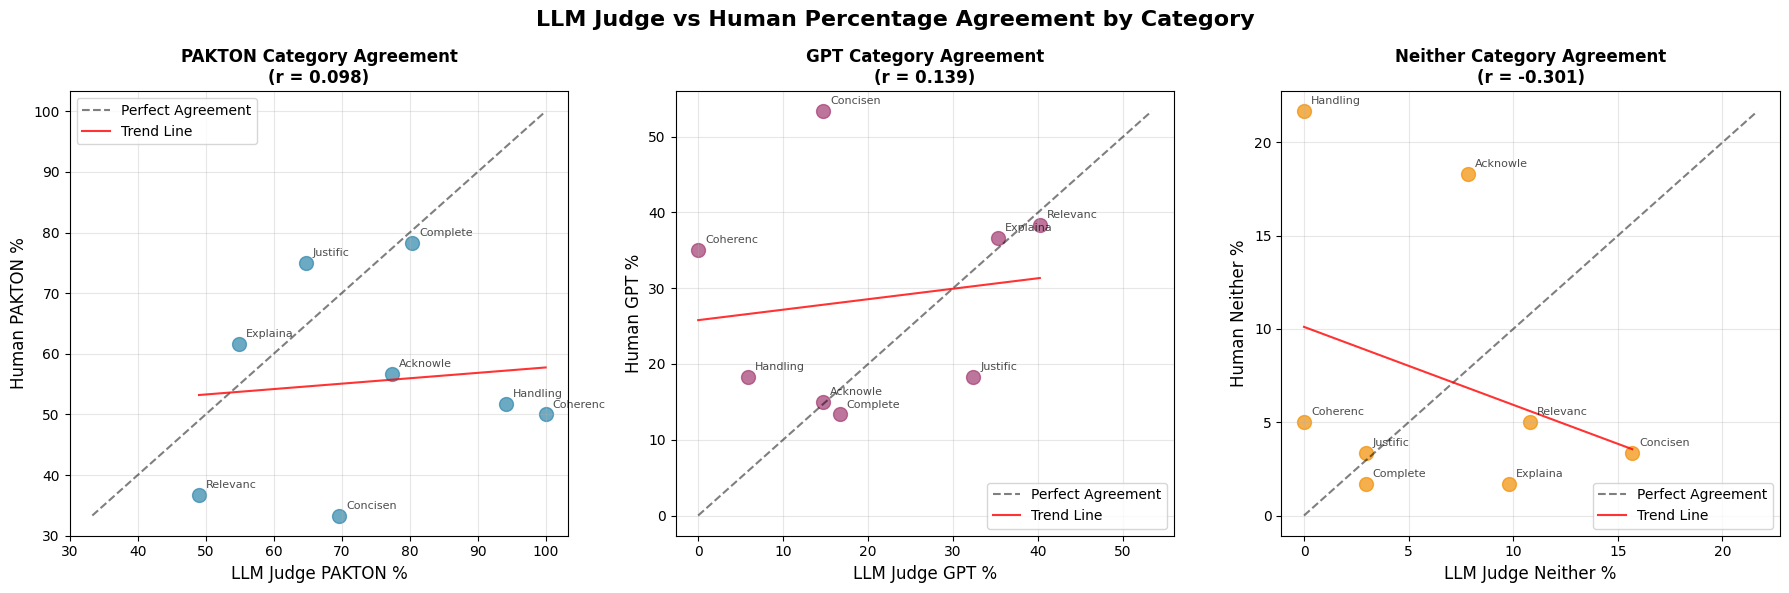

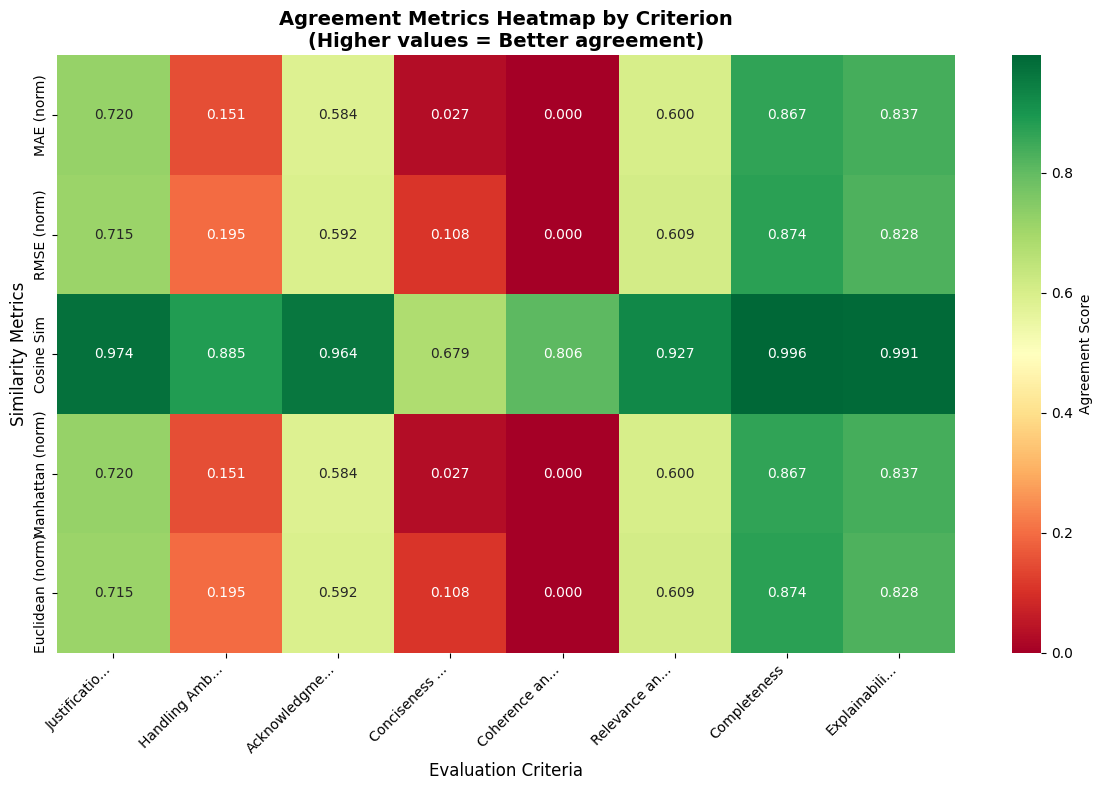

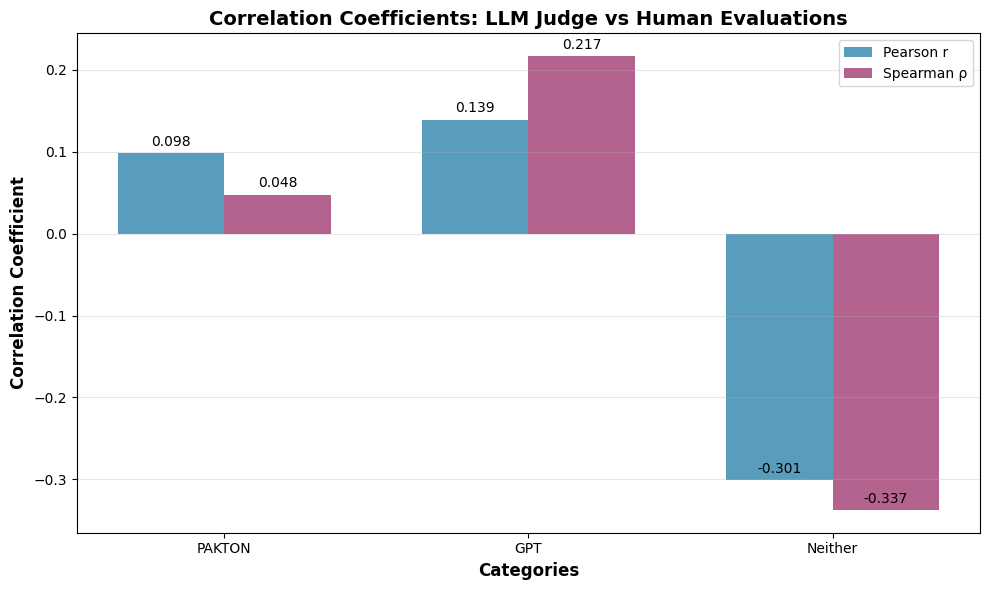

In [16]:
# Visualization of Agreement Analysis
print("\n" + "=" * 80)
print("AGREEMENT VISUALIZATIONS")
print("=" * 80)

# 1. Scatter plots for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
categories = ['PAKTON', 'GPT', 'Neither']
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, (category, color) in enumerate(zip(categories, colors)):
    llm_values = alignment_df[f'llm_{category.lower()}_pct']
    human_values = alignment_df[f'human_{category.lower()}_pct']
    
    axes[i].scatter(llm_values, human_values, alpha=0.7, color=color, s=100)
    
    # Add diagonal line for perfect agreement
    min_val = min(min(llm_values), min(human_values))
    max_val = max(max(llm_values), max(human_values))
    axes[i].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Agreement')
    
    # Add regression line
    z = np.polyfit(llm_values, human_values, 1)
    p = np.poly1d(z)
    axes[i].plot(llm_values.sort_values(), p(llm_values.sort_values()), "r-", alpha=0.8, label='Trend Line')
    
    axes[i].set_xlabel(f'LLM Judge {category} %', fontsize=12)
    axes[i].set_ylabel(f'Human {category} %', fontsize=12)
    axes[i].set_title(f'{category} Category Agreement\n(r = {correlation_results[category]["pearson_r"]:.3f})', 
                      fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()
    
    # Add criterion labels to points
    for j, row in alignment_df.iterrows():
        axes[i].annotate(row['criterion'][:8], 
                        (row[f'llm_{category.lower()}_pct'], row[f'human_{category.lower()}_pct']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.suptitle('LLM Judge vs Human Percentage Agreement by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Heatmap of agreement metrics
fig, ax = plt.subplots(figsize=(12, 8))

# Create a matrix for heatmap (criteria vs metrics)
metrics_matrix = similarity_df[['mae', 'rmse', 'cosine_similarity', 'manhattan_distance', 'euclidean_distance']].T
criteria_short = [c[:12] + '...' if len(c) > 12 else c for c in similarity_df['criterion']]

# Normalize metrics for better visualization (lower is better for most, higher for cosine)
normalized_matrix = metrics_matrix.copy()
for metric in ['mae', 'rmse', 'manhattan_distance', 'euclidean_distance']:
    normalized_matrix.loc[metric] = 1 - (normalized_matrix.loc[metric] / normalized_matrix.loc[metric].max())

sns.heatmap(normalized_matrix, 
            xticklabels=criteria_short,
            yticklabels=['MAE (norm)', 'RMSE (norm)', 'Cosine Sim', 'Manhattan (norm)', 'Euclidean (norm)'],
            annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Agreement Score'})

ax.set_title('Agreement Metrics Heatmap by Criterion\n(Higher values = Better agreement)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Evaluation Criteria', fontsize=12)
ax.set_ylabel('Similarity Metrics', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Bar plot of correlation coefficients
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['PAKTON', 'GPT', 'Neither']
pearson_values = [correlation_results[cat]['pearson_r'] for cat in categories]
spearman_values = [correlation_results[cat]['spearman_r'] for cat in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, pearson_values, width, label='Pearson r', alpha=0.8, color='#2E86AB')
bars2 = ax.bar(x + width/2, spearman_values, width, label='Spearman ρ', alpha=0.8, color='#A23B72')

ax.set_xlabel('Categories', fontsize=12, fontweight='bold')
ax.set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Correlation Coefficients: LLM Judge vs Human Evaluations', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
# Comprehensive Agreement Summary and Interpretation
print("=" * 80)
print("COMPREHENSIVE AGREEMENT ANALYSIS SUMMARY")
print("=" * 80)

# Overall agreement assessment
overall_mae = similarity_df['mae'].mean()
overall_cosine = similarity_df['cosine_similarity'].mean()
avg_pearson = np.mean([correlation_results[cat]['pearson_r'] for cat in categories])

# Create agreement categories
def categorize_agreement(mae, cosine_sim):
    if mae <= 5 and cosine_sim >= 0.95:
        return "Excellent"
    elif mae <= 10 and cosine_sim >= 0.90:
        return "Good"
    elif mae <= 15 and cosine_sim >= 0.80:
        return "Moderate"
    elif mae <= 25 and cosine_sim >= 0.70:
        return "Fair"
    else:
        return "Poor"

overall_agreement = categorize_agreement(overall_mae, overall_cosine)

print(f"OVERALL AGREEMENT LEVEL: {overall_agreement}")
print(f"Average MAE: {overall_mae:.2f}% (Lower is better)")
print(f"Average Cosine Similarity: {overall_cosine:.4f} (Higher is better)")
print(f"Average Pearson Correlation: {avg_pearson:.4f}")

print(f"\nINTERPRETATION:")
print(f"• The LLM Judge and Human evaluations show {overall_agreement.lower()} agreement overall")
if overall_mae <= 10:
    print(f"• The average percentage difference of {overall_mae:.1f}% suggests the methods are quite aligned")
elif overall_mae <= 20:
    print(f"• The average percentage difference of {overall_mae:.1f}% suggests moderate alignment")
else:
    print(f"• The average percentage difference of {overall_mae:.1f}% suggests significant divergence")

print(f"\nKEY FINDINGS:")

# Find best and worst categories
best_category = max(categories, key=lambda x: correlation_results[x]['pearson_r'])
worst_category = min(categories, key=lambda x: correlation_results[x]['pearson_r'])

print(f"• Best category alignment: {best_category} (r = {correlation_results[best_category]['pearson_r']:.3f})")
print(f"• Worst category alignment: {worst_category} (r = {correlation_results[worst_category]['pearson_r']:.3f})")

# Criteria-specific insights
best_criterion = similarity_df.loc[similarity_df['cosine_similarity'].idxmax(), 'criterion']
worst_criterion = similarity_df.loc[similarity_df['cosine_similarity'].idxmin(), 'criterion']

print(f"• Most aligned criterion: {best_criterion} (cosine similarity: {similarity_df['cosine_similarity'].max():.4f})")
print(f"• Least aligned criterion: {worst_criterion} (cosine similarity: {similarity_df['cosine_similarity'].min():.4f})")

print(f"\nSTATISTICAL SIGNIFICANCE:")
significant_correlations = 0
for category in categories:
    if correlation_results[category]['pearson_p'] < 0.05:
        significant_correlations += 1
        print(f"• {category}: Statistically significant correlation (p = {correlation_results[category]['pearson_p']:.4f})")
    else:
        print(f"• {category}: Not statistically significant (p = {correlation_results[category]['pearson_p']:.4f})")

print(f"\nRECOMMENDations:")
if overall_agreement in ["Excellent", "Good"]:
    print("• The LLM Judge shows strong alignment with human evaluations")
    print("• Consider using LLM Judge as a cost-effective alternative for large-scale evaluations")
elif overall_agreement == "Moderate":
    print("• The LLM Judge shows reasonable alignment but may need calibration")
    print("• Consider hybrid approach: LLM pre-screening + human validation")
else:
    print("• Significant differences detected between LLM and human evaluations")
    print("• Human evaluation remains preferred for critical assessments")
    print("• LLM Judge may need prompt engineering or model fine-tuning")

# Create a final summary table
print(f"\n" + "=" * 60)
print("METRIC SUMMARY TABLE")
print("=" * 60)
print(f"{'Metric':<25} {'Value':<15} {'Interpretation':<20}")
print("-" * 60)
print(f"{'Overall Agreement':<25} {overall_agreement:<15} {'Based on MAE & Cosine':<20}")
print(f"{'Average MAE':<25} {overall_mae:.2f}%{'':<9} {'Lower = Better':<20}")
print(f"{'Average Cosine Sim':<25} {overall_cosine:.4f}{'':<10} {'Higher = Better':<20}")
print(f"{'Avg Pearson r':<25} {avg_pearson:.4f}{'':<10} {'Closer to ±1 = Better':<20}")
print(f"{'Significant Corr.':<25} {significant_correlations}/{len(categories)}{'':<11} {'p < 0.05':<20}")

print(f"\n" + "=" * 60)
print("METHODOLOGY NOTES")
print("=" * 60)
print("• Pearson correlation: Measures linear relationship strength")
print("• Spearman correlation: Measures monotonic relationship (rank-based)")
print("• Cosine similarity: Measures vector similarity (1 = identical, 0 = orthogonal)")
print("• MAE: Mean Absolute Error in percentage points")
print("• Analysis based on percentage distributions, not individual sample agreement")
print("• Statistical significance tested at α = 0.05 level")

COMPREHENSIVE AGREEMENT ANALYSIS SUMMARY
OVERALL AGREEMENT LEVEL: Moderate
Average MAE: 13.17% (Lower is better)
Average Cosine Similarity: 0.9029 (Higher is better)
Average Pearson Correlation: -0.0212

INTERPRETATION:
• The LLM Judge and Human evaluations show moderate agreement overall
• The average percentage difference of 13.2% suggests moderate alignment

KEY FINDINGS:
• Best category alignment: GPT (r = 0.139)
• Worst category alignment: Neither (r = -0.301)
• Most aligned criterion: Completeness (cosine similarity: 0.9958)
• Least aligned criterion: Conciseness and Precision (cosine similarity: 0.6795)

STATISTICAL SIGNIFICANCE:
• PAKTON: Not statistically significant (p = 0.8169)
• GPT: Not statistically significant (p = 0.7423)
• Neither: Not statistically significant (p = 0.4687)

RECOMMENDations:
• The LLM Judge shows reasonable alignment but may need calibration
• Consider hybrid approach: LLM pre-screening + human validation

METRIC SUMMARY TABLE
Metric                   

In [10]:
# Analysis Excluding "Contextual and Legal Understanding" Criterion
print("=" * 80)
print("STATISTICAL AGREEMENT ANALYSIS (EXCLUDING 'Contextual and Legal Understanding')")
print("=" * 80)

# Filter out the "Contextual and Legal Understanding" criterion
excluded_criterion = "Contextual and Legal Understanding"
filtered_alignment_df = alignment_df[alignment_df['criterion'] != excluded_criterion].copy()

print(f"Original criteria count: {len(alignment_df)}")
print(f"Filtered criteria count: {len(filtered_alignment_df)}")
print(f"Excluded criterion: {excluded_criterion}")
print()

# Recalculate correlation analysis for filtered data
print("FILTERED CORRELATION ANALYSIS:")
print("=" * 50)

categories = ['PAKTON', 'GPT', 'Neither']
filtered_correlation_results = {}

for category in categories:
    llm_values = filtered_alignment_df[f'llm_{category.lower()}_pct'].values
    human_values = filtered_alignment_df[f'human_{category.lower()}_pct'].values
    
    pearson_corr, pearson_p = pearsonr(llm_values, human_values)
    spearman_corr, spearman_p = spearmanr(llm_values, human_values)
    
    filtered_correlation_results[category] = {
        'pearson_r': pearson_corr,
        'pearson_p': pearson_p,
        'spearman_r': spearman_corr,
        'spearman_p': spearman_p
    }
    
    print(f"\n{category} Category (Filtered):")
    print(f"  Pearson correlation: r = {pearson_corr:.4f}, p = {pearson_p:.4f}")
    print(f"  Spearman correlation: ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")
    print(f"  Change from original: Pearson Δr = {pearson_corr - correlation_results[category]['pearson_r']:+.4f}")

# Recalculate similarity metrics for filtered data
print(f"\n" + "=" * 50)
print("FILTERED DISTRIBUTION SIMILARITY METRICS:")
print("=" * 50)

filtered_similarity_metrics = []

for _, row in filtered_alignment_df.iterrows():
    llm_dist = [row['llm_pakton_pct'], row['llm_gpt_pct'], row['llm_neither_pct'], row['llm_unsure_pct']]
    human_dist = [row['human_pakton_pct'], row['human_gpt_pct'], row['human_neither_pct'], row['human_unsure_pct']]
    
    # Mean Absolute Error (MAE)
    mae = mean_absolute_error([llm_dist], [human_dist])
    
    # Root Mean Square Error (RMSE)
    rmse = np.sqrt(mean_squared_error([llm_dist], [human_dist]))
    
    # Cosine Similarity (1 - cosine distance)
    cosine_sim = 1 - cosine(llm_dist, human_dist)
    
    # Manhattan Distance
    manhattan_dist = sum(abs(l - h) for l, h in zip(llm_dist, human_dist))
    
    # Euclidean Distance
    euclidean_dist = np.sqrt(sum((l - h)**2 for l, h in zip(llm_dist, human_dist)))
    
    filtered_similarity_metrics.append({
        'criterion': row['criterion'],
        'mae': mae,
        'rmse': rmse,
        'cosine_similarity': cosine_sim,
        'manhattan_distance': manhattan_dist,
        'euclidean_distance': euclidean_dist
    })

filtered_similarity_df = pd.DataFrame(filtered_similarity_metrics)

# Compare filtered vs original metrics
filtered_overall_mae = filtered_similarity_df['mae'].mean()
filtered_overall_cosine = filtered_similarity_df['cosine_similarity'].mean()
filtered_avg_pearson = np.mean([filtered_correlation_results[cat]['pearson_r'] for cat in categories])

print(f"Original Average MAE: {overall_mae:.2f}%")
print(f"Filtered Average MAE: {filtered_overall_mae:.2f}% (Change: {filtered_overall_mae - overall_mae:+.2f}%)")
print(f"Original Average Cosine Similarity: {overall_cosine:.4f}")
print(f"Filtered Average Cosine Similarity: {filtered_overall_cosine:.4f} (Change: {filtered_overall_cosine - overall_cosine:+.4f})")
print(f"Original Average Pearson r: {avg_pearson:.4f}")
print(f"Filtered Average Pearson r: {filtered_avg_pearson:.4f} (Change: {filtered_avg_pearson - avg_pearson:+.4f})")

# Overall agreement assessment for filtered data
def categorize_agreement(mae, cosine_sim):
    if mae <= 5 and cosine_sim >= 0.95:
        return "Excellent"
    elif mae <= 10 and cosine_sim >= 0.90:
        return "Good"
    elif mae <= 15 and cosine_sim >= 0.80:
        return "Moderate"
    elif mae <= 25 and cosine_sim >= 0.70:
        return "Fair"
    else:
        return "Poor"

filtered_overall_agreement = categorize_agreement(filtered_overall_mae, filtered_overall_cosine)

print(f"\nOriginal Overall Agreement Level: {overall_agreement}")
print(f"Filtered Overall Agreement Level: {filtered_overall_agreement}")

if filtered_overall_agreement != overall_agreement:
    print(f"🔄 Agreement level changed from {overall_agreement} to {filtered_overall_agreement}")
else:
    print(f"✅ Agreement level remains {overall_agreement}")

# Show impact of excluded criterion
excluded_row = alignment_df[alignment_df['criterion'] == excluded_criterion].iloc[0]
excluded_llm_dist = [excluded_row['llm_pakton_pct'], excluded_row['llm_gpt_pct'], excluded_row['llm_neither_pct'], excluded_row['llm_unsure_pct']]
excluded_human_dist = [excluded_row['human_pakton_pct'], excluded_row['human_gpt_pct'], excluded_row['human_neither_pct'], excluded_row['human_unsure_pct']]
excluded_mae = mean_absolute_error([excluded_llm_dist], [excluded_human_dist])
excluded_cosine = 1 - cosine(excluded_llm_dist, excluded_human_dist)

print(f"\n" + "=" * 50)
print("IMPACT OF EXCLUDED CRITERION:")
print("=" * 50)
print(f"Excluded: {excluded_criterion}")
print(f"MAE for excluded criterion: {excluded_mae:.2f}%")
print(f"Cosine similarity for excluded criterion: {excluded_cosine:.4f}")
print(f"LLM distribution: PAKTON={excluded_row['llm_pakton_pct']:.1f}%, GPT={excluded_row['llm_gpt_pct']:.1f}%, Neither={excluded_row['llm_neither_pct']:.1f}%")
print(f"Human distribution: PAKTON={excluded_row['human_pakton_pct']:.1f}%, GPT={excluded_row['human_gpt_pct']:.1f}%, Neither={excluded_row['human_neither_pct']:.1f}%, Unsure={excluded_row['human_unsure_pct']:.1f}%")

if excluded_mae > filtered_overall_mae:
    print(f"📈 This criterion had WORSE agreement than average (MAE: {excluded_mae:.2f}% vs avg: {filtered_overall_mae:.2f}%)")
    print("   Excluding it IMPROVED overall agreement")
else:
    print(f"📉 This criterion had BETTER agreement than average (MAE: {excluded_mae:.2f}% vs avg: {filtered_overall_mae:.2f}%)")
    print("   Excluding it WORSENED overall agreement")

STATISTICAL AGREEMENT ANALYSIS (EXCLUDING 'Contextual and Legal Understanding')
Original criteria count: 9
Filtered criteria count: 8
Excluded criterion: Contextual and Legal Understanding

FILTERED CORRELATION ANALYSIS:

PAKTON Category (Filtered):
  Pearson correlation: r = 0.0983, p = 0.8169
  Spearman correlation: ρ = 0.0476, p = 0.9108
  Change from original: Pearson Δr = +0.2543

GPT Category (Filtered):
  Pearson correlation: r = 0.1392, p = 0.7423
  Spearman correlation: ρ = 0.2169, p = 0.6059
  Change from original: Pearson Δr = +0.2041

Neither Category (Filtered):
  Pearson correlation: r = -0.3010, p = 0.4687
  Spearman correlation: ρ = -0.3374, p = 0.4137
  Change from original: Pearson Δr = +0.0429

FILTERED DISTRIBUTION SIMILARITY METRICS:
Original Average MAE: 14.77%
Filtered Average MAE: 13.17% (Change: -1.60%)
Original Average Cosine Similarity: 0.8645
Filtered Average Cosine Similarity: 0.9029 (Change: +0.0384)
Original Average Pearson r: -0.1883
Filtered Average Pea


VISUAL COMPARISON: ORIGINAL vs FILTERED ANALYSIS


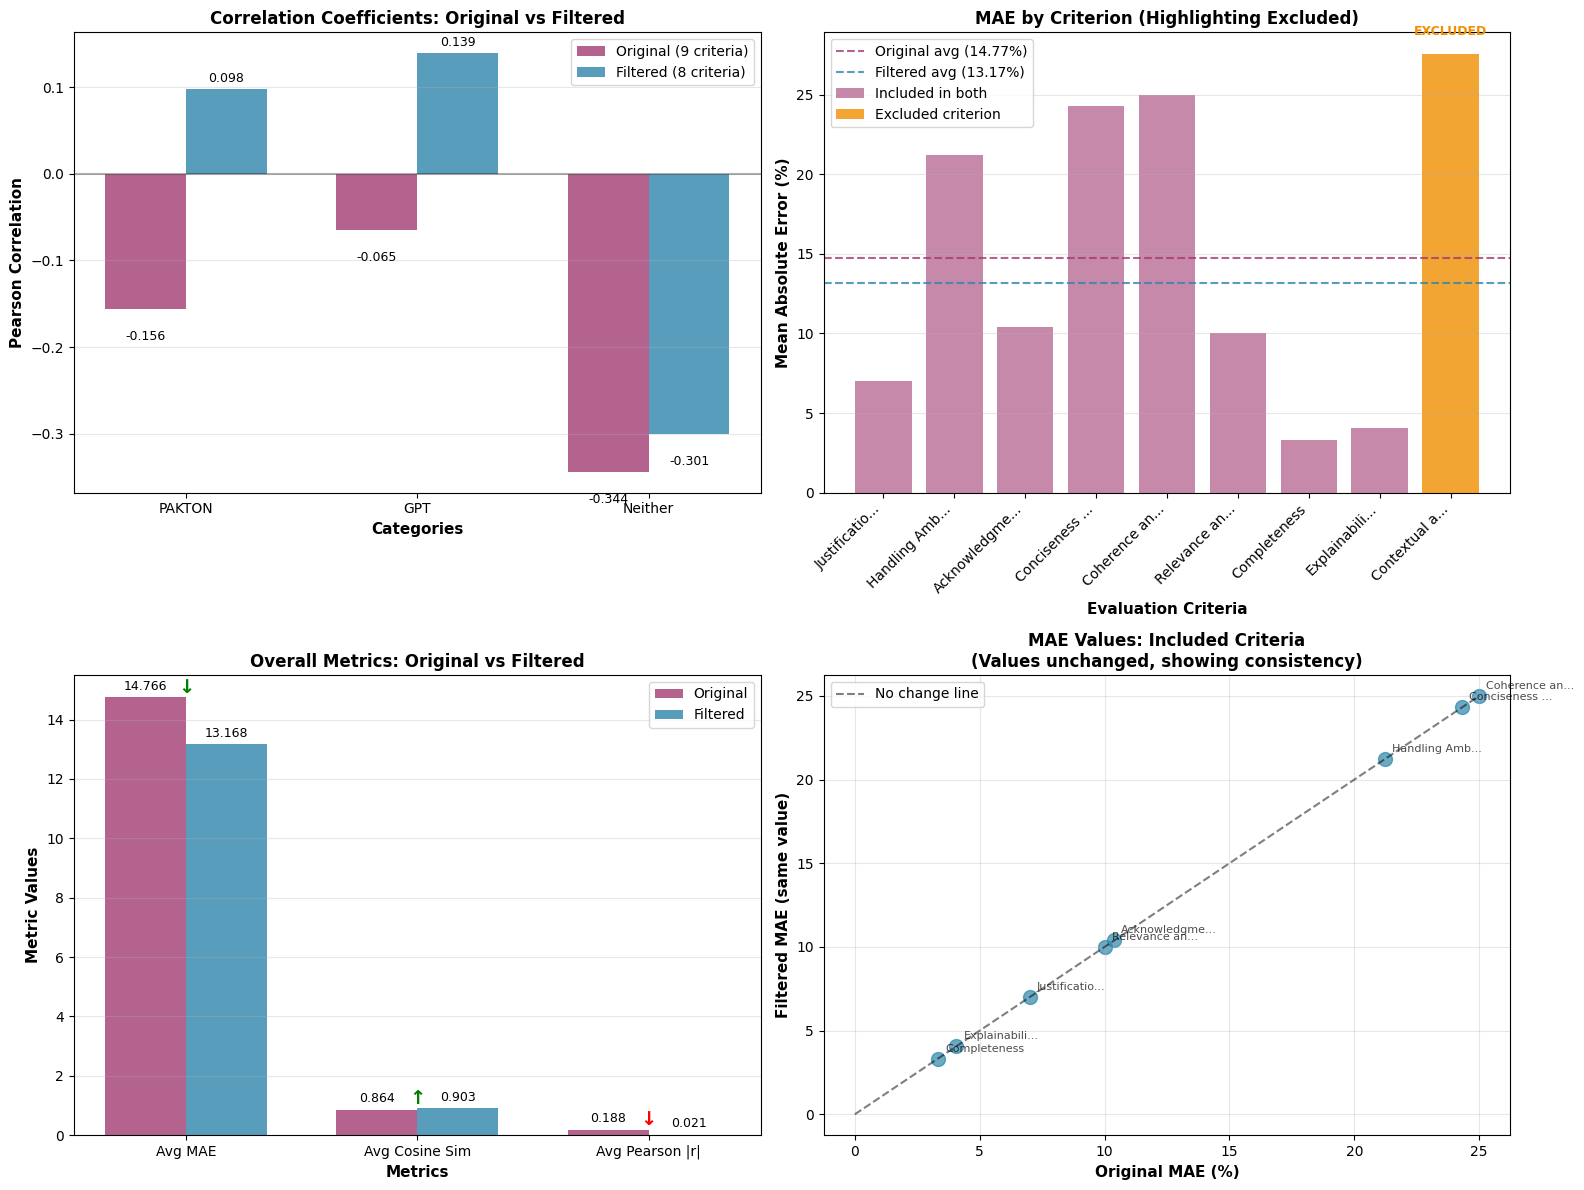


SUMMARY: IMPACT OF EXCLUDING 'Contextual and Legal Understanding'
                   Metric Original Filtered  Change     Interpretation
          Average MAE (%)    14.77    13.17   -1.60    Lower is better
Average Cosine Similarity   0.8645   0.9029 +0.0384   Higher is better
      Average |Pearson r|   0.1883   0.0212 -0.1671   Higher is better
          Agreement Level Moderate Moderate    Same Overall assessment

🎯 KEY FINDING: The 'Contextual and Legal Understanding' criterion was a major source of disagreement
   between LLM Judge and Human evaluators (MAE: 27.55% vs average: 13.17%)

💡 RECOMMENDATION: Consider this criterion for further analysis or prompt engineering to improve
   LLM Judge performance in legal context understanding.


In [11]:
# Visualization: Original vs Filtered Analysis Comparison
print("\n" + "=" * 80)
print("VISUAL COMPARISON: ORIGINAL vs FILTERED ANALYSIS")
print("=" * 80)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation coefficients comparison
categories = ['PAKTON', 'GPT', 'Neither']
original_pearson = [correlation_results[cat]['pearson_r'] for cat in categories]
filtered_pearson = [filtered_correlation_results[cat]['pearson_r'] for cat in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, original_pearson, width, label='Original (9 criteria)', alpha=0.8, color='#A23B72')
bars2 = ax1.bar(x + width/2, filtered_pearson, width, label='Filtered (8 criteria)', alpha=0.8, color='#2E86AB')

ax1.set_xlabel('Categories', fontsize=11, fontweight='bold')
ax1.set_ylabel('Pearson Correlation', fontsize=11, fontweight='bold')
ax1.set_title('Correlation Coefficients: Original vs Filtered', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3 if height >= 0 else -15),
                    textcoords="offset points",
                    ha='center', va='bottom' if height >= 0 else 'top',
                    fontsize=9)

# 2. MAE comparison by criterion
mae_comparison_data = []
for _, row in similarity_df.iterrows():
    criterion = row['criterion']
    original_mae = row['mae']
    
    if criterion == excluded_criterion:
        status = 'Excluded'
        filtered_mae = None
    else:
        filtered_row = filtered_similarity_df[filtered_similarity_df['criterion'] == criterion].iloc[0]
        filtered_mae = filtered_row['mae']
        status = 'Included'
    
    mae_comparison_data.append({
        'criterion': criterion[:12] + '...' if len(criterion) > 12 else criterion,
        'original_mae': original_mae,
        'filtered_mae': filtered_mae,
        'status': status
    })

mae_df = pd.DataFrame(mae_comparison_data)
included_df = mae_df[mae_df['status'] == 'Included']
excluded_df = mae_df[mae_df['status'] == 'Excluded']

x2 = np.arange(len(included_df))
ax2.bar(x2, included_df['original_mae'], alpha=0.6, color='#A23B72', label='Included in both')
ax2.axhline(y=overall_mae, color='#A23B72', linestyle='--', alpha=0.8, label=f'Original avg ({overall_mae:.2f}%)')
ax2.axhline(y=filtered_overall_mae, color='#2E86AB', linestyle='--', alpha=0.8, label=f'Filtered avg ({filtered_overall_mae:.2f}%)')

# Add excluded criterion as a highlighted bar
if len(excluded_df) > 0:
    excluded_x = len(included_df)
    ax2.bar(excluded_x, excluded_df.iloc[0]['original_mae'], alpha=0.8, color='#F18F01', label='Excluded criterion')
    ax2.text(excluded_x, excluded_df.iloc[0]['original_mae'] + 1, 'EXCLUDED', 
             ha='center', va='bottom', fontweight='bold', fontsize=9, color='#F18F01')

ax2.set_xlabel('Evaluation Criteria', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Absolute Error (%)', fontsize=11, fontweight='bold')
ax2.set_title('MAE by Criterion (Highlighting Excluded)', fontsize=12, fontweight='bold')
ax2.set_xticks(list(x2) + [excluded_x] if len(excluded_df) > 0 else x2)
ax2.set_xticklabels(list(included_df['criterion']) + list(excluded_df['criterion']) if len(excluded_df) > 0 else included_df['criterion'], 
                   rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Overall metrics comparison
metrics = ['Avg MAE', 'Avg Cosine Sim', 'Avg Pearson |r|']
original_values = [overall_mae, overall_cosine, abs(avg_pearson)]
filtered_values = [filtered_overall_mae, filtered_overall_cosine, abs(filtered_avg_pearson)]

x3 = np.arange(len(metrics))
bars3 = ax3.bar(x3 - width/2, original_values, width, label='Original', alpha=0.8, color='#A23B72')
bars4 = ax3.bar(x3 + width/2, filtered_values, width, label='Filtered', alpha=0.8, color='#2E86AB')

ax3.set_xlabel('Metrics', fontsize=11, fontweight='bold')
ax3.set_ylabel('Metric Values', fontsize=11, fontweight='bold')
ax3.set_title('Overall Metrics: Original vs Filtered', fontsize=12, fontweight='bold')
ax3.set_xticks(x3)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels and improvement indicators
for i, (orig, filt) in enumerate(zip(original_values, filtered_values)):
    ax3.annotate(f'{orig:.3f}', xy=(i - width/2, orig), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=9)
    ax3.annotate(f'{filt:.3f}', xy=(i + width/2, filt), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    # Add improvement indicator
    if i == 0:  # MAE (lower is better)
        improvement = "↓" if filt < orig else "↑"
        color = 'green' if filt < orig else 'red'
    else:  # Cosine and Pearson (higher is better)
        improvement = "↑" if filt > orig else "↓"
        color = 'green' if filt > orig else 'red'
    
    ax3.annotate(improvement, xy=(i, max(orig, filt) + 0.01), ha='center', va='bottom',
                fontsize=14, color=color, fontweight='bold')

# 4. Scatter plot: Original vs Filtered MAE values
included_original_mae = included_df['original_mae'].values
included_filtered_mae = included_df['filtered_mae'].values

ax4.scatter(included_original_mae, included_filtered_mae, alpha=0.7, color='#2E86AB', s=100)
ax4.plot([0, max(included_original_mae)], [0, max(included_original_mae)], 'k--', alpha=0.5, label='No change line')

# Add criterion labels
for i, row in included_df.iterrows():
    ax4.annotate(row['criterion'], 
                (row['original_mae'], row['filtered_mae']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

ax4.set_xlabel('Original MAE (%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Filtered MAE (same value)', fontsize=11, fontweight='bold')
ax4.set_title('MAE Values: Included Criteria\n(Values unchanged, showing consistency)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 70)
print("SUMMARY: IMPACT OF EXCLUDING 'Contextual and Legal Understanding'")
print("=" * 70)

summary_data = {
    'Metric': ['Average MAE (%)', 'Average Cosine Similarity', 'Average |Pearson r|', 'Agreement Level'],
    'Original': [f"{overall_mae:.2f}", f"{overall_cosine:.4f}", f"{abs(avg_pearson):.4f}", overall_agreement],
    'Filtered': [f"{filtered_overall_mae:.2f}", f"{filtered_overall_cosine:.4f}", f"{abs(filtered_avg_pearson):.4f}", filtered_overall_agreement],
    'Change': [f"{filtered_overall_mae - overall_mae:+.2f}", f"{filtered_overall_cosine - overall_cosine:+.4f}", 
               f"{abs(filtered_avg_pearson) - abs(avg_pearson):+.4f}", "Same" if filtered_overall_agreement == overall_agreement else f"{overall_agreement} → {filtered_overall_agreement}"],
    'Interpretation': ['Lower is better', 'Higher is better', 'Higher is better', 'Overall assessment']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n🎯 KEY FINDING: The 'Contextual and Legal Understanding' criterion was a major source of disagreement")
print(f"   between LLM Judge and Human evaluators (MAE: {excluded_mae:.2f}% vs average: {filtered_overall_mae:.2f}%)")
print(f"\n💡 RECOMMENDATION: Consider this criterion for further analysis or prompt engineering to improve")
print(f"   LLM Judge performance in legal context understanding.")